# NLP Sentiment Analysis con Long-Short Term Memory (LSTM)

En este notebook implemento un clasificador de sentimientos en inglés utilizando una arquitectura de red LSTM bidireccional. El objetivo es recorrer el flujo completo de un proyecto de NLP clásico con deep learning: limpieza de texto, tokenización, construcción de vocabulario, entrenamiento del modelo y evaluación cuantitativa y cualitativa de resultados.

#### Referencias
- Dataset: sentimentdataset.csv
- [Long Short-Term Memory](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory#fullTextFileContent)

> **Importante:** Antes de iniciar la ejecucion del notebook, verifica que el archivo `sentimentdataset.csv` exista en la ruta esperada.

---

# Universidad Icesi

## Maestria en IA Aplicada

Catedra: **Procesamiento de Lenguaje Natural**

Grupo: **Golf**
Realizado por:
- **Arlex Pino**
- **Alfredo Aponte**


---

## Contexto del problema y utilidad

Este notebook trabaja una tarea de **clasificacion multiclase de sentimientos** a partir de texto corto en ingles. El objetivo no es solo entrenar un modelo, sino entender el flujo completo de NLP clasico con deep learning: limpieza, tokenizacion, construccion de vocabulario, entrenamiento y evaluacion.

### Por que este problema es util
- Permite analizar opinion de usuarios en redes sociales, encuestas o soporte tecnico.
- Ayuda a priorizar casos criticos (por ejemplo, emociones negativas intensas).
- Es una base para sistemas de monitoreo de marca, riesgo reputacional y experiencia de cliente.
- Será utilizadas para actividades  de clasificación en las preguntas abiertas de las encuestas que los estudiantes registran de los cursos y los profesores con los cuales ven clases en la Universidad

En este ejercicio utilizo una LSTM porque es una arquitectura secuencial clara para aprender representaciones de texto tokenizado y sigue siendo un buen punto de partida antes de pasar a modelos de lenguaje más avanzados.

In [1]:
import importlib.metadata

# ==================================================================
# Detección de entorno de ejecución
# ==================================================================
# Identifica si el notebook se ejecuta en Google Colab o en un
# entorno local (VS Code, Jupyter clásico, etc).
# Esto es útil para ajustar configuraciones específicas del entorno.

installed_packages = [
    dist.metadata['Name'].lower()
    for dist in importlib.metadata.distributions()
    if dist.metadata['Name'] is not None
]
# Busca el paquete google-colab específico de Colab.
IN_COLAB = 'google-colab' in installed_packages

print(f"[Entorno] Detectado: {'Google Colab' if IN_COLAB else 'Local/VS Code'}")
print(f"[Entorno] Total de paquetes instalados: {len(installed_packages)}")

[Entorno] Detectado: Local/VS Code
[Entorno] Total de paquetes instalados: 211


Instalacion de librerias a utilizar en el proyecto desde el archivo Requirements.ttxt

In [2]:
import os
import re
import sys
import subprocess
import pandas as pd

import importlib.metadata as importlib_metadata

req_file = "requirements.txt"

if not os.path.exists(req_file):
    print(f"[Error] No existe '{req_file}' en el directorio actual.")
else:
    # -----------------------------
    # 1) Leer y parsear requirements
    # -----------------------------
    with open(req_file, "r", encoding="utf-8") as f:
        raw_lines = f.readlines()

    req_specs = []
    for line in raw_lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith(("-r", "--", "-f")):
            # Se omiten directivas especiales para este chequeo simple.
            continue
        req_specs.append(line)

    def split_name_and_exact_version(spec: str):
        """Extrae nombre de paquete y versión exacta si viene con ==."""
        m = re.match(r"^\s*([A-Za-z0-9_.\-]+)\s*(==\s*([^\s;]+))?.*$", spec)
        if not m:
            return spec, None
        pkg_name = m.group(1)
        exact_ver = m.group(3) if m.group(2) else None
        return pkg_name, exact_ver

    report_rows = []

    # -----------------------------
    # 2) Verificar instalación previa
    # -----------------------------
    for spec in req_specs:
        pkg, req_ver = split_name_and_exact_version(spec)

        try:
            installed_before = importlib_metadata.version(pkg)
            if req_ver is None:
                status = "instalada"
            else:
                status = "instalada_ok" if installed_before == req_ver else "version_distinta"
        except importlib_metadata.PackageNotFoundError:
            installed_before = None
            status = "no_instalada"

        report_rows.append(
            {
                "package": pkg,
                "spec": spec,
                "required_version": req_ver,
                "installed_before": installed_before,
                "status_before": status,
                "action": "ninguna",
                "install_result": "n/a",
                "installed_after": None,
                "status_final": None,
            }
        )

    # -----------------------------
    # 3) Instalar faltantes / desalineadas
    # -----------------------------
    for row in report_rows:
        needs_install = row["status_before"] in {"no_instalada", "version_distinta"}
        if not needs_install:
            row["action"] = "sin_cambios"
            try:
                row["installed_after"] = importlib_metadata.version(row["package"])
                row["status_final"] = "ok"
            except importlib_metadata.PackageNotFoundError:
                row["installed_after"] = None
                row["status_final"] = "error_no_detectada"
            continue

        row["action"] = f"pip install {row['spec']}"
        try:
            cmd = [sys.executable, "-m", "pip", "install", row["spec"]]
            proc = subprocess.run(cmd, capture_output=True, text=True)
            row["install_result"] = "ok" if proc.returncode == 0 else f"error ({proc.returncode})"

            try:
                row["installed_after"] = importlib_metadata.version(row["package"])
                if row["required_version"] is None:
                    row["status_final"] = "ok"
                else:
                    row["status_final"] = (
                        "ok" if row["installed_after"] == row["required_version"] else "version_distinta"
                    )
            except importlib_metadata.PackageNotFoundError:
                row["installed_after"] = None
                row["status_final"] = "error_no_detectada"
        except Exception as e:
            row["install_result"] = f"error ({e})"
            row["installed_after"] = None
            row["status_final"] = "error"

    # -----------------------------
    # 4) Reporte final
    # -----------------------------
    report_df = pd.DataFrame(report_rows)

    print("[Reporte] Resultado por librería:")
    display(report_df)

    resumen = report_df["status_final"].value_counts(dropna=False).rename_axis("estado").reset_index(name="cantidad")
    print("\n[Resumen final]:")
    display(resumen)

    report_path = "requirements_check_report.csv"
    report_df.to_csv(report_path, index=False, encoding="utf-8")
    print(f"[OK] Reporte guardado en: {report_path}")

[Reporte] Resultado por librería:


,package,spec,required_version,installed_before,status_before,action,install_result,installed_after,status_final
0,ipykernel,ipykernel==6.31.0,6.31.0,6.31.0,instalada_ok,sin_cambios,n/a,6.31.0,ok
1,jupyterlab,jupyterlab==4.0.8,4.0.8,4.0.8,instalada_ok,sin_cambios,n/a,4.0.8,ok
2,lightning,lightning==2.2.0.post0,2.2.0.post0,2.2.0.post0,instalada_ok,sin_cambios,n/a,2.2.0.post0,ok
3,matplotlib,matplotlib==3.8.0,3.8.0,3.8.0,instalada_ok,sin_cambios,n/a,3.8.0,ok
4,numpy,numpy==1.26.4,1.26.4,1.26.4,instalada_ok,sin_cambios,n/a,1.26.4,ok
5,pandas,pandas==2.1.1,2.1.1,2.1.1,instalada_ok,sin_cambios,n/a,2.1.1,ok
6,plotly,plotly==6.6.0,6.6.0,6.6.0,instalada_ok,sin_cambios,n/a,6.6.0,ok
7,scikit-learn,scikit-learn==1.3.0,1.3.0,1.3.0,instalada_ok,sin_cambios,n/a,1.3.0,ok
8,seaborn,seaborn==0.12.2,0.12.2,0.12.2,instalada_ok,sin_cambios,n/a,0.12.2,ok
9,tensorboard,tensorboard==2.16.2,2.16.2,2.16.2,instalada_ok,sin_cambios,n/a,2.16.2,ok



[Resumen final]:


,estado,cantidad
0,ok,14


[OK] Reporte guardado en: requirements_check_report.csv


## Reproducibilidad del experimento

Antes de comenzar el análisis fijamos semillas aleatorias para que, en la medida de lo posible, los resultados sean reproducibles.
Esto es importante porque permite volver a ejecutar el notebook desde cero y obtener un comportamiento consistente.

In [3]:
import random
import numpy as np

# ==================================================================
# Configuración de reproducibilidad
# ==================================================================
# Fija semillas aleatorias en Python, NumPy y PyTorch para garantizar
# que experimentos posteriores sean reproducibles. Esto es crítico para
# investigación científica y debugging consistente.

SEED = 42

# ------------------------------------------------------------------
# 1) Reproducibilidad en Python nativo y NumPy
# ------------------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)

torch_available = False
cuda_available = False

# ------------------------------------------------------------------
# 2) Reproducibilidad en PyTorch (CPU y GPU si aplica)
# ------------------------------------------------------------------
# Asegura que operaciones de red neuronal sean deterministas tanto
# en CPU como en CUDA, aunque puede afectar performance en GPU.
try:
    import torch

    torch_available = True
    cuda_available = torch.cuda.is_available()

    # Establece semilla para CPU y todos los GPUs.
    torch.manual_seed(SEED)
    if cuda_available:
        torch.cuda.manual_seed_all(SEED)

    # Fuerza algoritmos deterministas en cuDNN cuando están disponibles.
    # Nota: puede reducir performance pero mejora reproducibilidad.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception as e:
    print(f"[Aviso] No fue posible configurar semilla en PyTorch: {e}")

print(f"[Reproducibilidad] Semilla configurada: {SEED}")
print(f"[Reproducibilidad] PyTorch disponible: {torch_available}")
print(f"[Reproducibilidad] CUDA disponible: {cuda_available}")

[Reproducibilidad] Semilla configurada: 42
[Reproducibilidad] PyTorch disponible: True
[Reproducibilidad] CUDA disponible: True


### Cargando el dataset

Cargamos `sentimentdataset.csv`, que contiene pares **(Text, Sentiment)**. Cada fila representa un texto y su etiqueta calificada.

### Notas importantes sobre el dataset
- Es un dataset de lenguaje natural realista: puede tener etiquetas inconsistentes, variaciones semánticas y ruido típico de texto libre.
- Antes del entrenamiento, es necesario estandarizar etiquetas y limpiar valores vacíos.
- Algunas clases con muy pocos ejemplos se agrupan en la categoría `other` para reducir inestabilidad durante el entrenamiento.

Este preprocesamiento mejora la calidad de supervision y hace que el modelo aprenda patrones mas robustos.

In [4]:
import pandas as pd
import warnings
import os
import re
import matplotlib.pyplot as plt

# ==================================================================
# Configuración inicial del entorno y carga de datos
# ==================================================================
# Esta sección:
# 1. Configura advertencias y variables de entorno
# 2. Carga el dataset desde CSV
# 3. Realiza limpieza y validación de datos
# 4. Normaliza etiquetas de sentimiento
# 5. Filtra y agrupa clases para entrenamiento

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print("[Inicio] Preparando carga y limpieza del dataset...")
dataset_file = 'sentimentdataset.csv'

# Validación temprana para evitar traceback cuando el archivo no existe.
if not os.path.exists(dataset_file):
    print(f"[Error] No se encontró el archivo '{dataset_file}'.")
    print("[Error] Verifica la ruta o coloca el archivo en el mismo directorio del notebook.")

    # Variables seguras para evitar fallos en cascada.
    df_raw = pd.DataFrame(columns=['Text', 'Sentiment'])
    dataset = []
else:
    # ------------------------------------------------------------------
    # PASO 1: Carga del dataset
    # ------------------------------------------------------------------
    print(f"[1/5] Cargando dataset {dataset_file}...")
    df_raw = pd.read_csv(dataset_file)
    df_raw = df_raw[['Text', 'Sentiment']].copy()
    print(f"Registros iniciales: {len(df_raw)}")

    # ------------------------------------------------------------------
    # PASO 2: Limpieza básica de columnas
    # ------------------------------------------------------------------
    # Estandariza texto y etiqueta para evitar variaciones por espacios,
    # valores NaN o mayúsculas que compliquen análisis posterior.
    df_raw['Text'] = df_raw['Text'].fillna('').astype(str).str.strip()
    df_raw['Sentiment'] = df_raw['Sentiment'].fillna('').astype(str).str.strip()
    print("[2/5] Limpieza básica aplicada en columnas Text y Sentiment.")

    def normalize_sentiment_label(label: str) -> str:
        """Normaliza etiquetas de sentimiento a forma canónica.

        Pasos:
        1) pasa a minúscula
        2) elimina caracteres no alfabéticos
        3) unifica variantes/alias en clases principales
           (ej: 'happy' -> 'joy', 'sad' -> 'sadness')

        Args:
            label: Etiqueta original de sentimiento (str).

        Returns:
            Etiqueta normalizada a clase canónica.
        """
        label = str(label).strip().lower()
        label = re.sub(r"[^a-z\s\-]", "", label)
        label = label.replace('-', ' ')
        label = re.sub(r"\s+", " ", label).strip()

        # Mapeo de variantes a clases canónicas
        alias_map = {
            'joy': {'joy', 'happy', 'happiness', 'elation', 'euphoria', 'enthusiasm', 'amusement', 'overjoyed', 'playfuljoy', 'festivejoy', 'zest', 'celebration', 'contentment', 'serenity', 'positivity'},
            'sadness': {'sad', 'sadness', 'grief', 'despair', 'melancholy', 'heartbreak', 'sorrow', 'loss', 'loneliness', 'disappointment', 'devastated', 'desolation', 'heartache', 'ruins', 'darkness', 'exhaustion', 'lostlove', 'solitude'},
            'anger': {'anger', 'hate', 'frustration', 'frustrated', 'bitterness', 'bitter', 'resentment', 'betrayal', 'disgust', 'regret'},
            'fear': {'fear', 'fearful', 'anxiety', 'apprehensive', 'intimidation', 'helplessness', 'pressure', 'suffering', 'emotionalstorm'},
            'love': {'love', 'affection', 'adoration', 'gratitude', 'grateful', 'appreciation', 'compassion', 'compassionate', 'empathetic', 'kindness', 'friendship', 'romance', 'heartwarming', 'touched', 'connection'},
            'surprise': {'surprise', 'awe', 'amazement', 'wonder', 'wonderment', 'enchantment', 'captivation', 'marvel', 'thrill'}
        }

        # Busca si la etiqueta pertenece a algún conjunto de alias.
        for canonical_label, aliases in alias_map.items():
            if label in aliases:
                return canonical_label
        return label

    # ------------------------------------------------------------------
    # PASO 3: Normalización semántica de etiquetas
    # ------------------------------------------------------------------
    print("[3/5] Normalizando etiquetas de sentimiento...")
    df_raw['Sentiment_norm'] = df_raw['Sentiment'].apply(normalize_sentiment_label)

    # Filtra filas inválidas tras estandarizar.
    df_raw = df_raw[(df_raw['Text'] != '') & (df_raw['Sentiment_norm'] != '')].copy()
    normalized_counts = df_raw['Sentiment_norm'].value_counts()
    print(f"Etiquetas normalizadas detectadas: {normalized_counts.shape[0]}")

    # ------------------------------------------------------------------
    # PASO 4: Agrupación de clases raras en 'other'
    # ------------------------------------------------------------------
    # Clases con muy pocos ejemplos introducen ruido en entrenamiento.
    # Se agrupan bajo 'other' para mejorar stability y generalización.
    print("[4/5] Agrupando clases raras en 'other'...")
    min_samples_per_class = 10
    valid_classes = normalized_counts[normalized_counts >= min_samples_per_class].index
    df_raw['Sentiment'] = df_raw['Sentiment_norm'].where(
        df_raw['Sentiment_norm'].isin(valid_classes), 'other'
    )

    # ------------------------------------------------------------------
    # PASO 5: Construcción del dataset final para modelado
    # ------------------------------------------------------------------
    final_counts = df_raw['Sentiment'].value_counts()
    dataset = df_raw[['Text', 'Sentiment']].to_dict('records')

    print("[5/5] Dataset listo para modelado.")
    print(f"Total de registros finales: {len(dataset)}")
    print(f"Clases usadas en entrenamiento (inc. 'other'): {final_counts.shape[0]}")
    print("Distribución final de clases:")
    print(final_counts)

# Visualización de primeros registros.
df_raw[['Text', 'Sentiment']].head()

[Inicio] Preparando carga y limpieza del dataset...
[1/5] Cargando dataset sentimentdataset.csv...
Registros iniciales: 732
[2/5] Limpieza básica aplicada en columnas Text y Sentiment.
[3/5] Normalizando etiquetas de sentimiento...
Etiquetas normalizadas detectadas: 121
[4/5] Agrupando clases raras en 'other'...
[5/5] Dataset listo para modelado.
Total de registros finales: 732
Clases usadas en entrenamiento (inc. 'other'): 12
Distribución final de clases:
Sentiment
other         269
joy           128
sadness        68
love           47
anger          46
positive       45
excitement     37
surprise       31
neutral        18
fear           16
curiosity      16
nostalgia      11
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,positive
1,Traffic was terrible this morning.,other
2,Just finished an amazing workout! 💪,positive
3,Excited about the upcoming weekend getaway!,positive
4,Trying out a new recipe for dinner tonight.,neutral


### Análisis inicial del dataset

En este punto conviene revisar el tamaño del conjunto de datos, las primeras observaciones y la distribución de clases.
Esto permite responder preguntas clave para el caso de estudio:

- ¿Cuántos registros hay disponibles?
- ¿Las clases están balanceadas o desbalanceadas?
- ¿Los textos son cortos, medianos o largos?
- ¿El problema requerirá tratamiento especial por longitud o por frecuencia de etiquetas?

Los resultados de las siguientes celdas deben comentarse en función de este caso particular.

In [5]:
# ==================================================================
# Análisis exploratorio detallado de los datos
# ==================================================================
# Calcula estadísticas básicas y visualiza distribución de clases.

print("[EDA] Iniciando resumen general del dataset...")
print(f"Cantidad de registros: {len(df_raw)}")
print("Columnas analizadas:", list(df_raw.columns))
display(df_raw.head())

# Si el dataset está vacío, detenemos análisis visual para evitar errores.
if df_raw.empty:
    print("[EDA] El dataset está vacío. No es posible calcular distribuciones ni gráficas.")
else:
    # ------------------------------------------------------------------
    # Distribución de clases de sentimiento
    # ------------------------------------------------------------------
    print("[EDA] Calculando distribución de clases...")
    class_distribution = df_raw['Sentiment'].value_counts().sort_values(ascending=False)
    display(class_distribution.to_frame(name='conteo'))

[EDA] Iniciando resumen general del dataset...
Cantidad de registros: 732
Columnas analizadas: ['Text', 'Sentiment', 'Sentiment_norm']


,Text,Sentiment,Sentiment_norm
0,Enjoying a beautiful day at the park!,positive,positive
1,Traffic was terrible this morning.,other,negative
2,Just finished an amazing workout! 💪,positive,positive
3,Excited about the upcoming weekend getaway!,positive,positive
4,Trying out a new recipe for dinner tonight.,neutral,neutral


[EDA] Calculando distribución de clases...


,conteo
Sentiment,
other,269
joy,128
sadness,68
love,47
anger,46
positive,45
excitement,37
surprise,31
neutral,18


In [6]:
# ==================================================================
# Análisis de longitud de textos
# ==================================================================
# Calcula estadísticas sobre longitud de textos (número de caracteres).
# Útil para decidir max_length en tokenización y padding.

if not df_raw.empty:
    # Calcula longitud de texto para cada registro (en caracteres).
    text_lengths = [len(str(text)) for text in df_raw['Text']]
    
    # Estadísticas de distribución.
    lengths = np.array(text_lengths)
    p50 = np.percentile(lengths, 50)
    p75 = np.percentile(lengths, 75)
    p90 = np.percentile(lengths, 90)
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)

    print("[Longitud] Estadísticas de longitud de textos:")
    print(f"  Mínimo: {lengths.min()}")
    print(f"  Máximo: {lengths.max()}")
    print(f"  Promedio: {lengths.mean():.2f}")
    print(f"  Mediana (p50): {p50:.0f}")
    print(f"  Percentil 75: {p75:.0f}")
    print(f"  Percentil 90: {p90:.0f}")
    print(f"  Percentil 95: {p95:.0f}")
    print(f"  Percentil 99: {p99:.0f}")

[Longitud] Estadísticas de longitud de textos:
  Mínimo: 27
  Máximo: 156
  Promedio: 84.43
  Mediana (p50): 82
  Percentil 75: 108
  Percentil 90: 131
  Percentil 95: 137
  Percentil 99: 147


In [7]:
# ==================================================================
# Visualización 1: Distribución de sentimientos (barras horizontal)
# ==================================================================
# Crea gráfica interactiva con Plotly que muestra cantidad de registros
# por clase de sentimiento. Útil para detectar desbalance de clases.

import plotly.express as px

if not df_raw.empty:
    # Prepara datos: tabla con clases y sus conteos.
    class_data = class_distribution.reset_index()
    class_data.columns = ['Sentiment', 'Count']
    class_data = class_data.sort_values('Count', ascending=True)

    # Crear gráfica interactiva color-coded: más registros = color más brillante.
    fig = px.bar(
        class_data,
        x='Count',
        y='Sentiment',
        orientation='h',  # Barras horizontales para mejor legibilidad.
        color='Count',
        color_continuous_scale='Viridis',  # Escala de color.
        title='<b>Distribución de Clases de Sentimiento en el Dataset</b>',
        labels={'Count': 'Cantidad de registros', 'Sentiment': 'Clase de Sentimiento'},
        height=600,
        text='Count'  # Muestra valor de Count encima de cada barra.
    )

    # Personalización de trazas: etiquetas y bordes.
    fig.update_traces(
        textposition='outside',
        texttemplate='%{text}',
        marker=dict(line=dict(color='white', width=2))
    )

    # Personalización de layout: fuentes, colores de fondo, interactividad.
    fig.update_layout(
        font=dict(size=12, family='Arial, sans-serif'),
        title_font_size=16,
        xaxis_title_font_size=14,
        yaxis_title_font_size=14,
        showlegend=False,
        hovermode='closest',
        plot_bgcolor='rgba(240, 240, 245, 0.5)',
    )

    fig.show()

In [8]:
# ==================================================================
# Visualización 2: Distribución de sentimientos (gráfico circular)
# ==================================================================
# Crea gráfico circular (pie chart) que muestra proporción porcentual
# de cada clase. Complementa el gráfico anterior mostrando proporción relativa.

if not df_raw.empty:
    # Prepara datos: calcula percentages para cada clase.
    pct_values = (class_distribution.values / class_distribution.sum() * 100).tolist()
    pct_labels = [f"{label}: {pct:.1f}%" for label, pct in zip(class_distribution.index, pct_values)]

    # Crea pie chart interactivo.
    pie_data = pd.DataFrame({
        'Sentiment': class_distribution.index,
        'Count': class_distribution.values
    })

    fig_pie = px.pie(
        pie_data,
        values='Count',
        names='Sentiment',
        title='<b>Proporción de Sentimientos en el Dataset</b>',
        color_discrete_sequence=px.colors.qualitative.Set3,
        height=600
    )

    # Personalización: muestra porcentaje en hover y personalizaformat.
    fig_pie.update_traces(
        textposition='auto',
        textinfo='label+percent',
        hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Porcentaje: %{percent}<extra></extra>'
    )

    fig_pie.update_layout(
        font=dict(size=12, family='Arial, sans-serif'),
        title_font_size=16,
        showlegend=True,
        hovermode='closest'
    )

    fig_pie.show()

## Análisis de la Distribución de Clases

La gráfica anterior muestra la distribución de las etiquetas de sentimiento presentes en el dataset después del proceso de limpieza y normalización.

El conjunto de datos contiene **732 registros distribuidos en 12 clases de sentimiento**, lo que permite observar cómo se reparte la frecuencia de cada etiqueta dentro del corpus.

### Observaciones principales

1. **Desbalance de clases**

El dataset presenta un **desbalance significativo entre las clases**.  
La clase **`other`** es la más frecuente con **269 registros**, mientras que la menos frecuente es **`nostalgia`** con **11 registros**.

Esto genera un **ratio de desbalance aproximado de 24.45 entre la clase más grande y la más pequeña**, lo cual indica una distribución altamente desigual.

2. **Clases dominantes**

Las clases con mayor representación en el dataset son:

- `other`: 269 registros  
- `joy`: 128 registros  
- `sadness`: 68 registros  

Estas clases concentran una proporción considerable de los ejemplos disponibles y, por lo tanto, tienen mayor probabilidad de influir en el aprendizaje del modelo.

3. **Clases con baja representación**

Varias categorías presentan **muy pocos ejemplos**, entre ellas:

- `nostalgia`: 11
- `fear`: 16
- `curiosity`: 16
- `neutral`: 18

Las clases con pocas muestras pueden ser **difíciles de aprender para el modelo**, ya que existe menor información disponible para capturar patrones representativos.

4. **Riesgo de sesgo en el modelo**

Debido al desbalance observado, existe el riesgo de que el modelo tienda a **favorecer la predicción de las clases más frecuentes**, especialmente `other` y `joy`.  
Esto podría provocar que el modelo obtenga una **accuracy aparentemente alta**, pero con bajo desempeño en clases minoritarias.

5. **Implicaciones para la evaluación**

En escenarios con desbalance de clases, **la accuracy por sí sola no es suficiente para evaluar el rendimiento del modelo**.  
Es recomendable utilizar métricas que consideren el desempeño por clase, tales como:

- **Macro F1-score**
- **Recall por clase**
- **Matriz de confusión**

Estas métricas permiten evaluar de manera más justa la capacidad del modelo para identificar correctamente tanto las clases frecuentes como las menos representadas.

### Conclusión

El análisis de la distribución de clases evidencia que el dataset presenta un **desbalance considerable entre las etiquetas de sentimiento**.  
Por esta razón, durante el entrenamiento del modelo se implementan estrategias como **ponderación de clases (`class_weights`) y muestreo balanceado (`WeightedRandomSampler`)**, con el objetivo de mitigar el sesgo hacia las clases dominantes y mejorar la capacidad de generalización del modelo.

Observemos uno de sus registros

In [9]:
# ==================================================================
# Inspección de un registro del dataset
# ==================================================================
# Visualiza la estructura de un ejemplo individual para entender
# qué datos tenemos: texto + etiqueta de sentimiento asociada.

print("[Inspección] Estructura y contenido de ejemplo del dataset:")
dataset[1]

[Inspección] Estructura y contenido de ejemplo del dataset:


{'Text': 'Traffic was terrible this morning.', 'Sentiment': 'other'}

In [10]:
# ==================================================================
# Análisis estadístico: Longitud de textos
# ==================================================================
# Calcula estadísticas sobre longitud de textos para decidir un
# max_length razonable durante tokenización. Esto impacta en:
# - Cuántos tokens procesamos por texto
# - Cuánto padding aplicamos a textos cortos
# - El tamaño de entrada de la red neuronal

if not dataset:
    print("[Longitudes] Dataset vacío. No es posible calcular estadísticas.")
else:
    # Longevera en caracteres (no tokens) para cada registro.
    text_lengths = [len(row['Text']) for row in dataset]

    print(f"[Longitudes] Registros analizados: {len(text_lengths)}")
    print(f"Texto más corto: {min(text_lengths)} caracteres")
    print(f"Texto más largo: {max(text_lengths)} caracteres")
    print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.2f} caracteres")

[Longitudes] Registros analizados: 732
Texto más corto: 27 caracteres
Texto más largo: 156 caracteres
Longitud promedio: 84.43 caracteres


[Dashboard] Generando panel de análisis de longitudes...


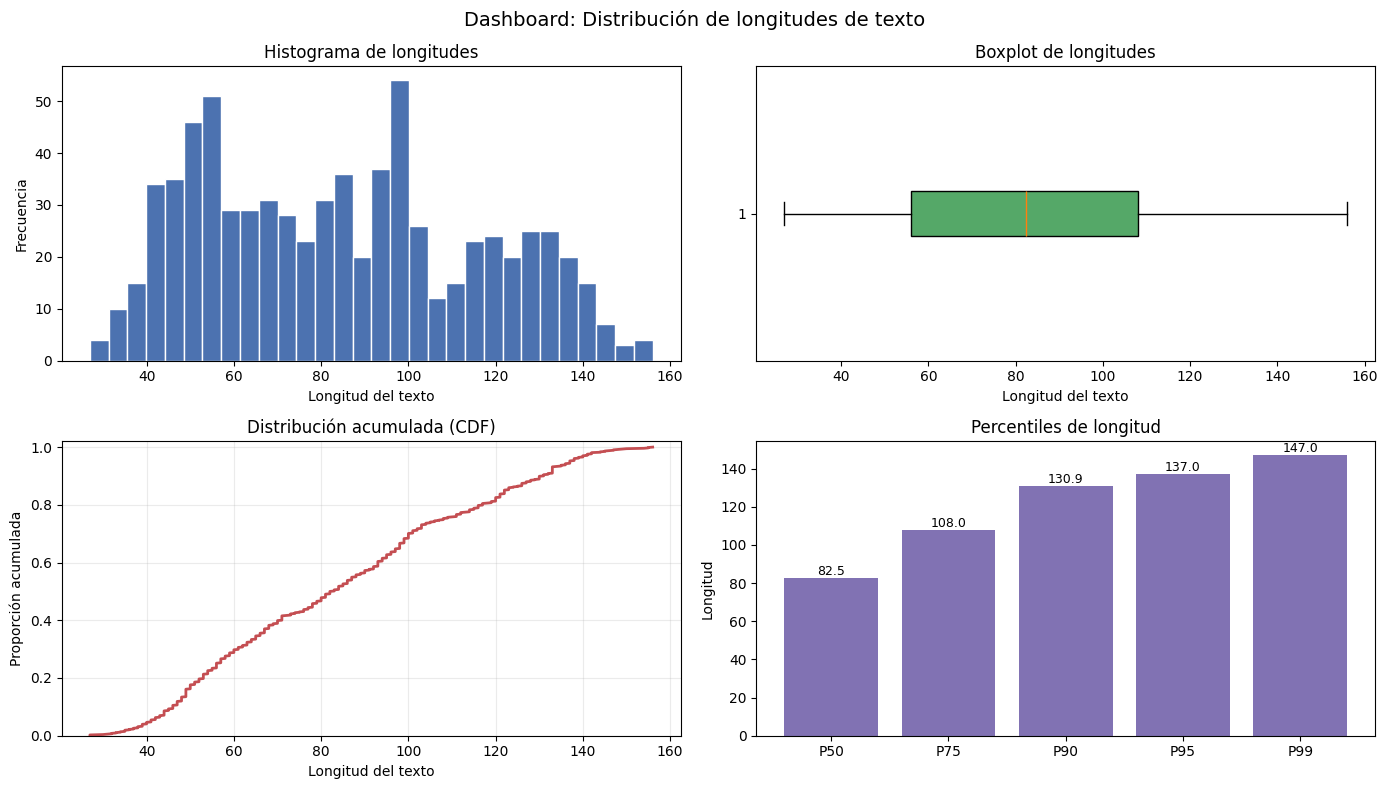

[Dashboard] P50=82.5 | P75=108.0 | P90=130.9 | P95=137.0 | P99=147.0


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ==================================================================
# Dashboard interactivo: Análisis de longitudes de textos
# ==================================================================
# Visualiza distribución de longitudes de texto desde 4 perspectivas:
# 1) Histograma: forma general de la distribución
# 2) Boxplot: detección de outliers y dispersión
# 3) CDF (Función de distribución acumulada): percentiles visuales
# 4) Percentiles clave: P50, P75, P90, P95, P99

if 'text_lengths' not in globals():
    if dataset:
        text_lengths = [len(row['Text']) for row in dataset]
    else:
        text_lengths = []

if len(text_lengths) == 0:
    print("[Dashboard] No hay datos de longitudes para graficar.")
else:
    lengths = np.array(text_lengths)
    p50, p75, p90, p95, p99 = np.percentile(lengths, [50, 75, 90, 95, 99])

    print("[Dashboard] Generando panel de análisis de longitudes...")
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Dashboard: Distribución de longitudes de texto', fontsize=14)

    # (1) Histograma principal: muestra forma de distribución.
    # Bins=30 agrupa datos en 30 intervalos para visualización clara.
    axes[0, 0].hist(lengths, bins=30, color='#4C72B0', edgecolor='white')
    axes[0, 0].set_title('Histograma de longitudes')
    axes[0, 0].set_xlabel('Longitud del texto')
    axes[0, 0].set_ylabel('Frecuencia')

    # (2) Boxplot: visualiza rango intercuartil, mediana y outliers.
    # Útil para detectar valores extremos que puedan afectar el modelo.
    axes[0, 1].boxplot(lengths, vert=False, patch_artist=True, boxprops=dict(facecolor='#55A868'))
    axes[0, 1].set_title('Boxplot de longitudes')
    axes[0, 1].set_xlabel('Longitud del texto')

    # (3) CDF (Función de distribución acumulada):
    # Muestra qué porcentaje de textos tiene longitud <= x.
    sorted_lengths = np.sort(lengths)
    cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    axes[1, 0].plot(sorted_lengths, cumulative, color='#C44E52', linewidth=2)
    axes[1, 0].set_title('Distribución acumulada (CDF)')
    axes[1, 0].set_xlabel('Longitud del texto')
    axes[1, 0].set_ylabel('Proporción acumulada')
    axes[1, 0].set_ylim(0, 1.02)
    axes[1, 0].grid(alpha=0.25)

    # (4) Resumen de percentiles: ayuda a elegir max_length para tokenización.
    # ejemplo: si P95=500, entonces ~95% de textos tienen ≤500 caracteres.
    pct_labels = ['P50', 'P75', 'P90', 'P95', 'P99']
    pct_values = [p50, p75, p90, p95, p99]
    axes[1, 1].bar(pct_labels, pct_values, color='#8172B3')
    axes[1, 1].set_title('Percentiles de longitud')
    axes[1, 1].set_ylabel('Longitud')
    for i, v in enumerate(pct_values):
        axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"[Dashboard] P50={p50:.1f} | P75={p75:.1f} | P90={p90:.1f} | P95={p95:.1f} | P99={p99:.1f}")

### Análisis de la Distribución de Longitudes de Texto

La figura anterior presenta un análisis exploratorio de la longitud de los textos presentes en el dataset. Este análisis es importante porque permite definir parámetros clave del pipeline de NLP, como la longitud máxima de secuencia utilizada durante la tokenización y el padding.

El dashboard incluye cuatro visualizaciones complementarias: un histograma de longitudes, un boxplot, la distribución acumulada (CDF) y un análisis de percentiles.

#### 1. Distribución general de longitudes

El histograma muestra que las longitudes de texto se distribuyen aproximadamente entre **30 y 160 caracteres**, con una mayor concentración de ejemplos entre **50 y 110 caracteres**.

Esto indica que la mayoría de los textos tienen una longitud moderada y relativamente homogénea, lo cual facilita el proceso de modelado al reducir la variabilidad extrema en las secuencias.

#### 2. Análisis de dispersión

El **boxplot** permite observar la dispersión de los datos:

- La **mediana** de longitud se encuentra aproximadamente en **82 caracteres**.
- El rango intercuartílico se ubica aproximadamente entre **60 y 105 caracteres**.
- No se observan valores extremadamente atípicos que puedan afectar significativamente el entrenamiento.

Esto sugiere que el dataset tiene una distribución relativamente estable en términos de longitud textual.

#### 3. Distribución acumulada (CDF)

La función de distribución acumulada permite entender qué proporción de los textos se encuentra por debajo de ciertas longitudes.

Por ejemplo:

- Aproximadamente **50% de los textos tienen menos de 82 caracteres**.
- Cerca del **75% de los textos tienen menos de 108 caracteres**.
- Alrededor del **90% de los textos tienen menos de 131 caracteres**.

Este análisis es especialmente útil para decidir el tamaño máximo de secuencia que se utilizará durante el entrenamiento.

#### 4. Percentiles relevantes

El gráfico de percentiles resume los valores clave de la distribución:

| Percentil | Longitud aproximada |
|-----------|---------------------|
| P50 | 82 |
| P75 | 108 |
| P90 | 131 |
| P95 | 137 |
| P99 | 147 |

Esto indica que **el 99% de los textos tiene menos de 147 caracteres**, lo cual permite establecer una longitud máxima razonable sin perder información relevante.

#### 5. Implicaciones para el preprocesamiento

A partir de este análisis se pueden tomar decisiones informadas para el pipeline de NLP:

- Definir una **longitud máxima de secuencia cercana a 150 tokens/caracteres** para cubrir casi todos los ejemplos.
- Aplicar **padding** para secuencias más cortas.
- Aplicar **truncamiento** únicamente a casos muy largos, que representan una pequeña fracción del dataset.

Esto permite optimizar el uso de memoria durante el entrenamiento y mantener una representación consistente de los textos.

#### Conclusión

El análisis de longitudes muestra que el dataset presenta **una distribución relativamente compacta y sin valores extremos significativos**. Esto facilita la definición de parámetros de tokenización y padding, y contribuye a un entrenamiento más estable del modelo.

Establecer una longitud máxima cercana al **percentil 95–99** permite capturar casi toda la información textual del dataset, manteniendo al mismo tiempo eficiencia computacional.

In [12]:
import re
from collections import Counter

# ==================================================================
# Construcción del tokenizador y vocabulario
# ==================================================================
# Esta sección transforma texto en tokens y construye un vocabulario
# con dos tokens especiales:
# - [PAD]: para rellenar secuencias cortas
# - [UNK]: para representar palabras no vistas en entrenamiento

def simple_tokenizer(text: str) -> list:
    """Tokenizador básico: minúsculas, limpieza y separación por espacios.
    
    Args:
        text: Texto a tokenizar.
        
    Returns:
        Lista de tokens (palabras en minúscula, caracteres no-alfabéticos removidos).
    """
    text = str(text).lower()
    # Reemplaza caracteres no-alfabéticos con espacios (mantiene límites de palabras).
    text = re.sub(r"[^a-z]+", " ", text)
    return text.strip().split()

# Valida que el dataset no esté vacío antes de construir vocabulario.
if not dataset:
    print("[Vocab] Dataset vacío. No se puede construir vocabulario.")
    token_counts = Counter()
    top_n_tokens = []
    vocab = {"[PAD]": 0, "[UNK]": 1}
else:
    print("[Vocab] Construyendo frecuencias de tokens...")
    # Tokeniza todos los textos y cuenta frecuencias de tokens.
    token_counts = Counter()
    for row in dataset:
        token_counts.update(simple_tokenizer(row["Text"]))

    # Limita el vocabulario a 10k tokens totales (incluyendo especiales).
    # Esto controla memoria y reduce ruido de palabras muy raras.
    max_vocab_size = 10000
    top_n_tokens = [tok for tok, _ in token_counts.most_common(max_vocab_size - 2)]

    # Construye vocabulario: mapea token_string -> token_id.
    # [PAD]=0 y [UNK]=1 son tokens especiales cero-indexados.
    vocab = {"[PAD]": 0, "[UNK]": 1}
    for token in top_n_tokens:
        vocab[token] = len(vocab)

    print(f"[Vocab] Tokens únicos encontrados: {len(token_counts)}")
    print(f"[Vocab] Vocabulario final construido: {len(vocab)} tokens")

def tokenize_text(text: str, max_length: int = 50) -> list:
    """Convierte texto en ids de tokens y aplica truncamiento/padding a longitud fija.
    
    Args:
        text: Texto a tokenizar.
        max_length: Longitud fija de salida (trunca si es más largo, padding si es más corto).
        
    Returns:
        Lista de ids de token de tamaño exactamente max_length.
    """
    # Tokeniza el texto.
    tokens = simple_tokenizer(text)
    # Mapea tokens a ids: usa vocab[UNK] para palabras no vistas.
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    # Rellena con [PAD] (id=0) hasta llegar a max_length.
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

[Vocab] Construyendo frecuencias de tokens...
[Vocab] Tokens únicos encontrados: 2530
[Vocab] Vocabulario final construido: 2532 tokens


In [13]:
# ==================================================================
# Inspección del vocabulario construido
# ==================================================================
# Revisa la diversidad léxica, distribución de frecuencias y
# cobertura del vocabulario para validar que sea equilibrado.

vocab_size = len(vocab)
num_tokens_no_special = len(top_n_tokens)

print(f"[Vocab-Inspect] Vocabulario total (inc. [PAD] y [UNK]): {vocab_size} tokens")
print(f"[Vocab-Inspect] Tokens de contenido (sin especiales): {num_tokens_no_special}")

if num_tokens_no_special == 0:
    print("[Vocab-Inspect] No hay tokens para mostrar (dataset vacío o sin texto válido).")
else:
    # Primeros tokens: palabras más frecuentes (funcionales, poco semántico).
    print("Primeros 15 tokens frecuentes:")
    print(top_n_tokens[:15])

    # Tokens de zona intermedia: palabras con contenido semántico relevante.
    # Estas suelen ser más discriminativas para la tarea de clasificación.
    print("15 tokens de una zona intermedia:")
    mid_start = min(1000, max(0, num_tokens_no_special - 15))
    print(top_n_tokens[mid_start:mid_start + 15])

    # Últimos tokens: palabras menos frecuentes, cola larga de distribución.
    # Responsables de low-frequency OOV (out-of-vocabulary) en entrenamiento.
    print("Últimos 15 tokens del vocabulario:")
    print(top_n_tokens[-15:])

[Vocab-Inspect] Vocabulario total (inc. [PAD] y [UNK]): 2532 tokens
[Vocab-Inspect] Tokens de contenido (sin especiales): 2530
Primeros 15 tokens frecuentes:
['the', 'a', 'of', 'in', 'to', 'and', 'with', 'for', 'on', 'by', 's', 'through', 'at', 'an', 'new']
15 tokens de una zona intermedia:
['suspense', 'cinematic', 'erupts', 'seats', 'spectators', 'tennis', 'display', 'basketball', 'finals', 'odds', 'golf', 'golfer', 'soccer', 'find', 'anticipated']
Últimos 15 tokens del vocabulario:
['pal', 'country', 'globe', 'enthusiasts', 'collaboration', 'spreading', 'track', 'regional', 'triumphs', 'company', 'fundraising', 'initiative', 'giving', 'multicultural', 'bringing']


## Análisis del vocabulario construido

Después del proceso de tokenización y construcción del vocabulario, se obtuvo un total de **2532 tokens**, incluyendo los tokens especiales `[PAD]` y `[UNK]`. Si se excluyen estos tokens especiales, el vocabulario contiene **2530 tokens de contenido real**.

### Tamaño del vocabulario

Considerando que el dataset contiene **732 registros**, el tamaño del vocabulario puede considerarse **moderado**. Esto sugiere que el corpus presenta una **diversidad léxica razonable**, sin llegar a un nivel excesivo de dispersión que complique el aprendizaje del modelo.

Un vocabulario demasiado grande podría introducir muchas palabras poco frecuentes, lo que incrementaría el **costo computacional**, la **dimensionalidad del espacio de embeddings** y el riesgo de **sobreajuste a términos raros**. En este caso, el tamaño obtenido parece mantener un equilibrio adecuado entre **capacidad de representación del lenguaje y eficiencia del modelo**.

### Tokens más frecuentes

Entre los tokens más frecuentes aparecen palabras funcionales comunes del inglés, como:

the, a, of, in, to, and, with, for, on, by, s, through, at, an, new

Este comportamiento es esperado en la mayoría de los corpus textuales, ya que estas palabras cumplen funciones gramaticales importantes dentro de las oraciones. Aunque tienen poco contenido semántico, ayudan al modelo a capturar la **estructura básica del lenguaje**.

### Tokens de frecuencia intermedia

En la zona media del vocabulario aparecen palabras con mayor contenido semántico, por ejemplo:

suspense, cinematic, erupts, spectators, tennis, basketball, finals, golfer, soccer

Este tipo de palabras suele aportar **mayor valor informativo para el modelo**, ya que representan conceptos más específicos del contenido del texto. En tareas de clasificación de sentimientos o temas, estos términos suelen ser **más discriminativos** que las palabras funcionales.

### Tokens menos frecuentes

Los tokens ubicados al final del vocabulario corresponden a palabras **poco frecuentes**, tales como:

pal, globe, enthusiasts, collaboration, fundraising, multicultural

Estas palabras aparecen en muy pocos ejemplos y forman parte de la **cola larga de la distribución léxica**. Este comportamiento es típico en los corpus de lenguaje natural y está relacionado con la **distribución Zipfiana**, donde pocas palabras aparecen con mucha frecuencia mientras que muchas palabras aparecen solo ocasionalmente.

### Implicaciones para el modelo

El tamaño y la distribución del vocabulario tienen varias implicaciones para el entrenamiento del modelo. El **embedding layer** deberá aprender representaciones para aproximadamente **2500 tokens**, lo cual es manejable computacionalmente. La presencia de palabras raras justifica el uso del token especial `[UNK]` para representar términos fuera de vocabulario.

En general, las palabras frecuentes ayudan al modelo a capturar **patrones estructurales del lenguaje**, mientras que las palabras de frecuencia media aportan **información semántica relevante para la tarea de clasificación**.

Por lo que , el vocabulario construido refleja una **diversidad léxica coherente con el tamaño del dataset**. La combinación de palabras frecuentes, términos de contenido semántico medio y una cola de palabras raras corresponde al comportamiento esperado en datos de lenguaje natural.

Esta estructura proporciona una base adecuada para el entrenamiento del modelo, permitiendo representar el contenido textual del dataset sin introducir una complejidad excesiva en el espacio de representación.

Exploremos el vocabulario obtenido.

In [14]:
# Ejemplo rapido: convertir texto a ids con longitud fija.
# max_length=8 aplica truncamiento/padding para obtener exactamente 8 posiciones.
tokenized = tokenize_text("play golf", max_length=8)

# Visualizamos la secuencia tokenizada (ids segun el vocabulario).
tokenized

[620, 1012, 0, 0, 0, 0, 0, 0]

Lo que obtenemos de vuelta son los ids de cada token según el vocabulario. Ahora algo importante que notamos aquí es el *padding*, durante el entrenamiento, queremos que las secuencias sean de tamaño fijo, para asi operar comodamente con matrices. Pero ya vimos que no todos los textos tienen la misma longitud. Entonces que hacer? para los que son más largos que una longitud dada simplemente cortamos, pero para los que son más cortos, debemos *rellenar* lo faltante con un *token especial de relleno o padding*. Y es justo lo que definimos allí, cuando la cadena es inferior a 8 **tokens**, entonces debemos hacer padding hasta que se cumplan los 8.

Si queremos saber a que token exactamente hacen referencia estos ids, simplemente revisamos el vocabulario que hemos construido:

In [15]:
# Diccionario inverso del vocabulario: convierte id -> token.
# Ejemplo: si vocab['play'] = 123, entonces id_2_token[123] = 'play'.
id_2_token = {v: k for k, v in vocab.items()}

# Decodifica la secuencia tokenizada para inspeccionar los tokens reales,
# incluyendo [PAD] en posiciones agregadas por padding.
[id_2_token[token] for token in tokenized]

['play', 'golf', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Claramente vemos los 3 tokens como cadenas independientes (el padding se considera un token independiente).

### Definiendo el dataset de pytorch
Ahora podemos proceder a definir el dataset. Esto debería ser muy sencillo dado que nuestro dataset es pequeño y ya tenemos el tokenizador listo.

In [16]:
import importlib
import subprocess
import sys

# ------------------------------------------------------------------
# Verificacion e instalacion de PyTorch + diagnostico de CUDA
# ------------------------------------------------------------------
# Objetivo:
# 1) Asegurar que PyTorch este instalado.
# 2) Verificar si la build de PyTorch soporta CUDA.
# 3) Si hay build CPU-only, instalar build CUDA para Windows.

# Para GPUs NVIDIA modernas en Windows, cu121 suele ser estable.
PYTORCH_CUDA_INDEX = "https://download.pytorch.org/whl/cu121"

def install_torch_cuda_build() -> None:
    """Instala/actualiza PyTorch con soporte CUDA (build cu121)."""
    print("[PyTorch] Instalando build CUDA (cu121)...")
    install_cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
        "--index-url",
        PYTORCH_CUDA_INDEX,
    ]
    subprocess.check_call(install_cmd)
    print("[PyTorch] Instalacion CUDA finalizada.")

def ensure_pytorch_with_cuda():
    """Verifica PyTorch e intenta corregir si detecta build CPU-only."""
    restart_required = False
    try:
        torch_mod = importlib.import_module("torch")
        version = torch_mod.__version__
        cuda_build = torch_mod.version.cuda

        print(f"[PyTorch] Detectado. Version: {version}")
        print(f"[PyTorch] CUDA compilado en torch: {cuda_build}")

        cpu_only = ("+cpu" in version) or (cuda_build is None)
        if cpu_only:
            print("[PyTorch] Se detecto build CPU-only. No puede usar GPU.")
            install_torch_cuda_build()
            restart_required = True
        return torch_mod, restart_required

    except ImportError:
        print("[PyTorch] No instalado. Instalando build CUDA...")
        install_torch_cuda_build()
        # Necesario importar desde cero en la sesion actual.
        torch_mod = importlib.import_module("torch")
        return torch_mod, False

try:
    torch, needs_restart = ensure_pytorch_with_cuda()

    if needs_restart:
        # Si torch ya estaba cargado como CPU-only, hay que reiniciar kernel
        # para que Python cargue la nueva build CUDA instalada.
        print("\n[Accion requerida] Reinicia el kernel y vuelve a ejecutar esta celda.")
        print("[Accion requerida] Sin reinicio, seguira activa la version CPU en memoria.")
    else:
        # Diagnostico CUDA desde PyTorch
        cuda_ok = torch.cuda.is_available()
        print(f"[CUDA] Disponible en PyTorch: {cuda_ok}")
        print(f"[CUDA] Version CUDA en torch: {torch.version.cuda}")
        print(f"[CUDA] Numero de dispositivos: {torch.cuda.device_count()}")

        if cuda_ok:
            print(f"[CUDA] GPU activa: {torch.cuda.get_device_name(0)}")
        else:
            print("[CUDA] PyTorch no detecta GPU CUDA.")
            print("[CUDA] Revisa que el kernel use el entorno donde instalaste torch CUDA.")

    # Diagnostico adicional de sistema con nvidia-smi (si existe).
    try:
        out = subprocess.check_output(["nvidia-smi"], stderr=subprocess.STDOUT, text=True)
        print("\n[nvidia-smi] Disponible. Resumen:")
        print(out[:700])
    except Exception as e:
        print("\n[nvidia-smi] No disponible en este entorno:", e)

except Exception as e:
    print(f"[Error] Fallo durante verificacion/instalacion de PyTorch: {e}")

[PyTorch] Detectado. Version: 2.5.1+cu121
[PyTorch] CUDA compilado en torch: 12.1
[CUDA] Disponible en PyTorch: True
[CUDA] Version CUDA en torch: 12.1
[CUDA] Numero de dispositivos: 1
[CUDA] GPU activa: NVIDIA GeForce RTX 4070 Laptop GPU

[nvidia-smi] Disponible. Resumen:
Mon Mar  9 00:11:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.02                 Driver Version: 577.02         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RT


In [17]:
import torch
from typing import Callable, Dict
from torch.utils.data import Dataset


class SentimentDataset(Dataset):
    """Dataset de PyTorch para clasificacion de sentimientos.

    Cada elemento retorna:
    - `input_ids`: tensor con la secuencia tokenizada y pad/truncada.
    - `y`: tensor con el id numerico de la clase de sentimiento.
    """

    def __init__(self, tokenizer: Callable, data_list, seq_length: int = 128):
        # Tokenizador que convierte texto -> lista de ids.
        self.tokenizer = tokenizer
        # Lista de ejemplos con estructura {'Text': ..., 'Sentiment': ...}.
        self.data = data_list
        # Longitud fija para tokenizacion (padding/truncamiento).
        self.seq_length = seq_length

        # Construimos mapas de clases para convertir etiqueta <-> id.
        unique_labels = sorted(list(set(row['Sentiment'] for row in data_list)))
        self.id_2_class_map = dict(enumerate(unique_labels))
        self.class_2_id_map = {label: idx for idx, label in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Extrae texto y etiqueta original del ejemplo indexado.
        text = self.data[index]['Text']
        label = self.data[index]['Sentiment']

        # Convierte la etiqueta de texto a id de clase.
        y = self.class_2_id_map[label]

        # Convierte texto a ids con longitud fija.
        input_ids = torch.tensor(self.tokenizer(text, max_length=self.seq_length))

        return {
            'input_ids': input_ids,
            'y': torch.tensor(y),
        }

    def __len__(self):
        # Numero total de ejemplos del dataset.
        return len(self.data)

Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [18]:
# ==================================================================
# Validación: Instancia del dataset con SentimentDataset
# ==================================================================
# Crea una instancia del dataset custom de PyTorch que:
# 1. Tokeniza textos a longitud fija (128 tokens)
# 2. Mapea etiquetas de sentimiento a ids numéricos
# 3. Retorna tensores compatibles con DataLoaders
max_len = 128

print("[Dataset] Creando instancia de SentimentDataset...")
sentiment_dataset = SentimentDataset(
    tokenizer  = tokenize_text,
    data_list  = dataset,
    seq_length = max_len  # Longitud fija para todas las secuencias
)


# Verificación de consistencia: el dataset transformado debe conservar
# exactamente la misma cantidad de ejemplos que el dataset original.
assert len(sentiment_dataset) == len(dataset), (
    "El tamaño de SentimentDataset no coincide con el dataset original."
)

print(f"[Dataset] Dataset creado con {len(sentiment_dataset)} ejemplos")
print(f"[Dataset] Número de clases: {sentiment_dataset.num_classes}")
print(f"[Dataset] max_len configurado en: {max_len}")
print(f"[Dataset] Mapeo de clases: {sentiment_dataset.id_2_class_map}")

[Dataset] Creando instancia de SentimentDataset...
[Dataset] Dataset creado con 732 ejemplos
[Dataset] Número de clases: 12
[Dataset] max_len configurado en: 128
[Dataset] Mapeo de clases: {0: 'anger', 1: 'curiosity', 2: 'excitement', 3: 'fear', 4: 'joy', 5: 'love', 6: 'neutral', 7: 'nostalgia', 8: 'other', 9: 'positive', 10: 'sadness', 11: 'surprise'}


## Definicion del modelo LSTM

En esta seccion implementamos un clasificador de texto con tres bloques:
- Embeddings entrenables para convertir tokens en vectores densos.
- LSTM bidireccional para capturar dependencias de contexto.
- Capa densa final para producir la clase de sentimiento.

### Por que podria utilizarse este enfoque
- Cuando se necesita un baseline solido y explicable para clasificacion de texto.
- Cuando el volumen de datos es moderado y se requiere una arquitectura menos costosa que transformers grandes.
- Como punto de partida para comparar despues contra modelos mas avanzados (por ejemplo, BERT).

In [19]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
from collections import Counter

# ==================================================================
# Split de datos y creación de DataLoaders balanceados
# ==================================================================
# Esta sección:
# 1. Divide el dataset en train/val/test con estratificación
# 2. Crea WeightedRandomSampler para manejar desbalance de clases
# 3. construye DataLoaders para entrenamiento, validación y test

batch_size = 8
labels = [row['Sentiment'] for row in dataset]
all_indices = np.arange(len(dataset))

def safe_train_test_split(indices: np.ndarray, y_labels: list, test_size: float, random_state: int):
    """Realiza train_test_split con fallback a split no-estratificado.
    
    Intenta mantener proporción de clases en splits. Si falla (ej: clase muy rara),
    usa split aleatorio reproducible como fallback.
    
    Args:
        indices: Arreglo de índices a partir.
        y_labels: Etiquetas para estratificación.
        test_size: Proporción de test.
        random_state: Semilla para reproducibilidad.
        
    Returns:
        Tupla: (indices_train, indices_test), bool indicando si fue estratificado.
    """
    try:
        return train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=y_labels
        ), True
    except ValueError as e:
        print(f"[Aviso] Split estratificado no posible: {e}")
        print("[Aviso] Se utilizará split aleatorio reproducible para este paso.")
        return train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=None
        ), False

print("[Split] Distribución de clases completa:", Counter(labels))

# ------------------------------------------------------------------
# PASO 1: Train/Temp split (80/20)
# ------------------------------------------------------------------
(train_idx, temp_idx), stratified_main = safe_train_test_split(
    all_indices,
    labels,
    test_size=0.2,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]
print("[Split] Distribución de clases en temp:", Counter(temp_labels))

# ------------------------------------------------------------------
# PASO 2: Temp -> Val/Test split (50/50 de temp = 10/10% del total)
# ------------------------------------------------------------------
(val_idx, test_idx), stratified_temp = safe_train_test_split(
    temp_idx,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print(f"[Split] Split principal estratificado: {stratified_main}")
print(f"[Split] Split temp->val/test estratificado: {stratified_temp}")
print(f"[Split] Tamaños: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

# ------------------------------------------------------------------
# PASO 3: Crear subsets de PyTorch
# ------------------------------------------------------------------
train_dataset = Subset(sentiment_dataset, train_idx)
val_dataset = Subset(sentiment_dataset, val_idx)
test_dataset = Subset(sentiment_dataset, test_idx)

# ------------------------------------------------------------------
# PASO 4: Balanceo de clases para entrenamiento
# ------------------------------------------------------------------
# WeightedRandomSampler compensa desbalance muestreando con probabilidades.
# Clases raras se samplers más a menudo; clases frecuentes menos a menudo.
# Resultado: distribución más equilibrada durante entrenamiento.

train_label_ids = [sentiment_dataset.class_2_id_map[dataset[i]['Sentiment']] for i in train_idx]
# Conteo de ejemplos para cada clase en training.
class_counts = np.bincount(train_label_ids, minlength=sentiment_dataset.num_classes)
# Pesos inversamente proporcionales a frecuencia: clase rara -> peso alto.
class_weights_np = np.where(class_counts > 0, 1.0 / class_counts, 0.0)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)
# Sample weight: asigna peso a cada ejemplo según su clase.
sample_weights = torch.tensor([class_weights_np[y] for y in train_label_ids], dtype=torch.float32)
# WeightedRandomSampler samplers ejemplos según sus pesos.
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("[Balanceo] Distribución train (ids):", Counter(train_label_ids))
print("[Balanceo] Pesos de clase:", class_weights.tolist())

# ------------------------------------------------------------------
# PASO 5: Crear DataLoaders
# ------------------------------------------------------------------
# DataLoaders automatiza batching, shuffling y worker management.
# train_loader usa WeightedRandomSampler para balanceo.
# val/test_loaders sin shuffling (evaluación determinista).

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
print("[Dataloaders] train/val/test creados correctamente.")

[Split] Distribución de clases completa: Counter({'other': 269, 'joy': 128, 'sadness': 68, 'love': 47, 'anger': 46, 'positive': 45, 'excitement': 37, 'surprise': 31, 'neutral': 18, 'fear': 16, 'curiosity': 16, 'nostalgia': 11})
[Split] Distribución de clases en temp: Counter({'other': 54, 'joy': 26, 'sadness': 14, 'love': 10, 'positive': 9, 'anger': 9, 'excitement': 7, 'surprise': 6, 'neutral': 4, 'fear': 3, 'curiosity': 3, 'nostalgia': 2})
[Split] Split principal estratificado: True
[Split] Split temp->val/test estratificado: True
[Split] Tamaños: train=585, val=73, test=74
[Balanceo] Distribución train (ids): Counter({8: 215, 4: 102, 10: 54, 0: 37, 5: 37, 9: 36, 2: 30, 11: 25, 6: 14, 3: 13, 1: 13, 7: 9})
[Balanceo] Pesos de clase: [0.027027027681469917, 0.07692307978868484, 0.03333333507180214, 0.07692307978868484, 0.009803921915590763, 0.027027027681469917, 0.0714285746216774, 0.1111111119389534, 0.004651162773370743, 0.02777777798473835, 0.018518518656492233, 0.03999999910593033]
[

=== Tamaños de split ===


,n_muestras
train,585
val,73
test,74


=== Distribución por clase (conteos) ===


,train,val,test
anger,37,4,5
curiosity,13,2,1
excitement,30,3,4
fear,13,2,1
joy,102,13,13
love,37,5,5
neutral,14,2,2
nostalgia,9,1,1
other,215,27,27
positive,36,4,5


=== Ratio de desbalance (max/min por split) ===


,ratio_desbalance
train,23.888889
val,27.000000
test,27.000000


=== Efecto esperado del WeightedRandomSampler (train) ===


,train_real,train_muestreo_esperado
class,,
anger,37,48.75
curiosity,13,48.75
excitement,30,48.75
fear,13,48.75
joy,102,48.75
love,37,48.75
neutral,14,48.75
nostalgia,9,48.75
other,215,48.75


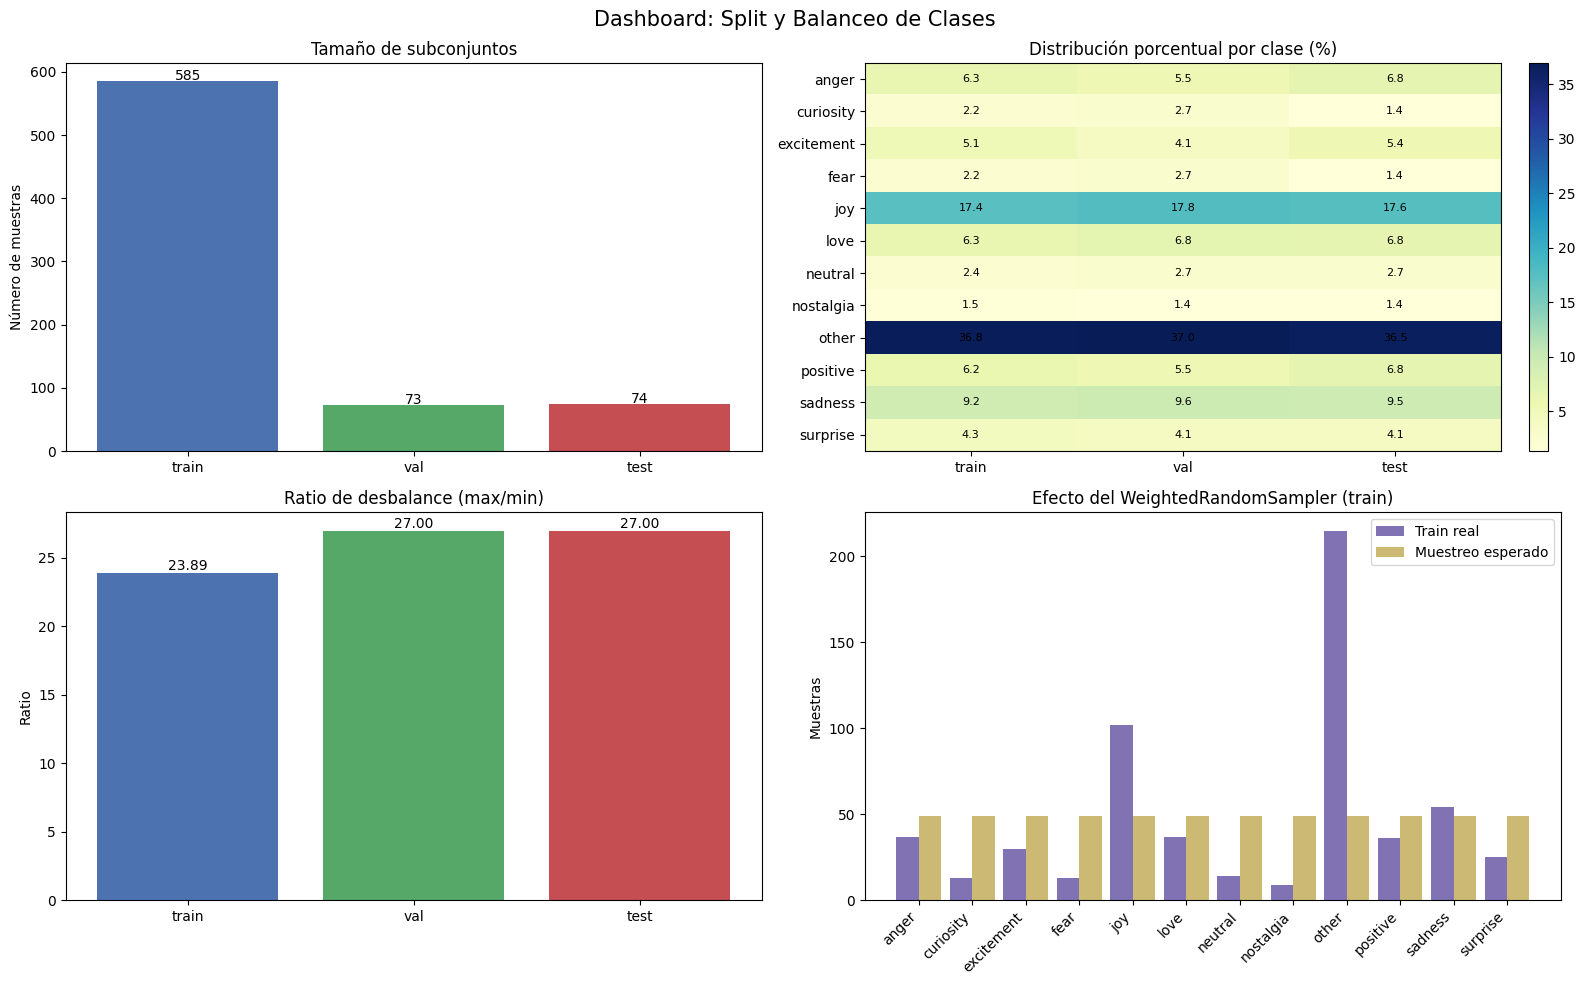

In [20]:
# Dashboard del split y balanceo de clases (train/val/test + WeightedRandomSampler)

# =========================
# 1) Tablas de resumen
# =========================
class_names = [sentiment_dataset.id_2_class_map[i] for i in range(sentiment_dataset.num_classes)]

train_labels_split = [dataset[i]["Sentiment"] for i in train_idx]
val_labels_split = [dataset[i]["Sentiment"] for i in val_idx]
test_labels_split = [dataset[i]["Sentiment"] for i in test_idx]

train_counts = pd.Series(train_labels_split).value_counts().reindex(class_names, fill_value=0)
val_counts = pd.Series(val_labels_split).value_counts().reindex(class_names, fill_value=0)
test_counts = pd.Series(test_labels_split).value_counts().reindex(class_names, fill_value=0)

counts_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
})
pct_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

# =========================
# 2) Efecto esperado del sampler
# =========================
weights_by_class = np.zeros(sentiment_dataset.num_classes, dtype=float)
for y, w in zip(train_label_ids, sample_weights.numpy()):
    weights_by_class[y] += float(w)

sampler_prob = weights_by_class / weights_by_class.sum()
expected_sampled_counts = sampler_prob * len(sample_weights)

sampler_df = pd.DataFrame({
    "class": class_names,
    "train_real": train_counts.values,
    "train_muestreo_esperado": expected_sampled_counts
}).set_index("class")

# =========================
# 3) Métricas rápidas de balanceo
# =========================
def imbalance_ratio(s):
    s = s[s > 0]
    return (s.max() / s.min()) if len(s) > 0 else np.nan

imbalance = pd.Series({
    "train": imbalance_ratio(train_counts),
    "val": imbalance_ratio(val_counts),
    "test": imbalance_ratio(test_counts)
})

split_sizes = pd.Series({
    "train": len(train_idx),
    "val": len(val_idx),
    "test": len(test_idx)
})

print("=== Tamaños de split ===")
display(split_sizes.to_frame("n_muestras"))

print("=== Distribución por clase (conteos) ===")
display(counts_df)

print("=== Ratio de desbalance (max/min por split) ===")
display(imbalance.to_frame("ratio_desbalance"))

print("=== Efecto esperado del WeightedRandomSampler (train) ===")
display(sampler_df.round(2))

# =========================
# 4) Dashboard
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard: Split y Balanceo de Clases", fontsize=15)

# (A) Tamaño de cada split
axes[0, 0].bar(split_sizes.index, split_sizes.values, color=["#4C72B0", "#55A868", "#C44E52"])
axes[0, 0].set_title("Tamaño de subconjuntos")
axes[0, 0].set_ylabel("Número de muestras")
for i, v in enumerate(split_sizes.values):
    axes[0, 0].text(i, v + 2, str(v), ha="center")

# (B) Heatmap manual de porcentajes por clase/split
heat_data = pct_df.values
im = axes[0, 1].imshow(heat_data, aspect="auto", cmap="YlGnBu")
axes[0, 1].set_title("Distribución porcentual por clase (%)")
axes[0, 1].set_xticks(np.arange(len(pct_df.columns)))
axes[0, 1].set_xticklabels(pct_df.columns)
axes[0, 1].set_yticks(np.arange(len(pct_df.index)))
axes[0, 1].set_yticklabels(pct_df.index)
for r in range(heat_data.shape[0]):
    for c in range(heat_data.shape[1]):
        axes[0, 1].text(c, r, f"{heat_data[r, c]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# (C) Ratio de desbalance por split
axes[1, 0].bar(imbalance.index, imbalance.values, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1, 0].set_title("Ratio de desbalance (max/min)")
axes[1, 0].set_ylabel("Ratio")
for i, v in enumerate(imbalance.values):
    axes[1, 0].text(i, v + 0.2, f"{v:.2f}", ha="center")

# (D) Train real vs esperado con sampler
x = np.arange(len(class_names))
width = 0.42
axes[1, 1].bar(x - width/2, train_counts.values, width, label="Train real", color="#8172B3")
axes[1, 1].bar(x + width/2, expected_sampled_counts, width, label="Muestreo esperado", color="#CCB974")
axes[1, 1].set_title("Efecto del WeightedRandomSampler (train)")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(class_names, rotation=45, ha="right")
axes[1, 1].set_ylabel("Muestras")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Análisis del particionamiento del dataset

En esta etapa se divide el conjunto de datos en entrenamiento, validación y prueba.
Esta decisión es fundamental porque:

- **entrenamiento** permite ajustar los pesos del modelo,
- **validación** ayuda a monitorear sobreajuste y seleccionar el mejor checkpoint,
- **prueba** sirve para medir el desempeño final en datos no usados durante el ajuste.

También es importante revisar la distribución de clases en cada subconjunto para confirmar que la evaluación sea representativa.

## Análisis del particionamiento del dataset

En esta etapa el dataset se divide en tres subconjuntos: **entrenamiento, validación y prueba**. Esta separación es fundamental en el desarrollo de modelos de aprendizaje automático, ya que cada subconjunto cumple un rol diferente dentro del proceso de entrenamiento y evaluación.

El subconjunto de **entrenamiento** se utiliza para ajustar los parámetros del modelo, el conjunto de **validación** permite monitorear el proceso de aprendizaje y prevenir sobreajuste, mientras que el conjunto de **prueba** se utiliza únicamente al final para estimar el desempeño real del modelo en datos no vistos.

### Tamaño de los subconjuntos

El dataset completo contiene **732 registros**, que fueron divididos de la siguiente manera:

- **Train:** 585 muestras  
- **Validation:** 73 muestras  
- **Test:** 74 muestras  

Esta división corresponde aproximadamente a un esquema **80% entrenamiento, 10% validación y 10% prueba**, lo que permite disponer de suficientes datos para entrenar el modelo mientras se reservan ejemplos para evaluar su capacidad de generalización.

### Estratificación de clases

El proceso de particionamiento se realizó utilizando **estratificación**, lo que significa que la distribución de clases se mantiene aproximadamente constante en cada subconjunto.

Esto se confirma en el dashboard de distribución porcentual, donde se observa que las proporciones de cada clase son muy similares entre **train, validation y test**.

Por ejemplo:

- La clase **`other`** representa aproximadamente **36–37%** de los datos en los tres subconjuntos.
- La clase **`joy`** se mantiene alrededor de **17–18%**.
- La clase **`sadness`** permanece cercana a **9–10%**.

La estratificación es importante porque evita que algunas clases queden subrepresentadas en los conjuntos de validación o prueba, lo que podría generar evaluaciones poco fiables del modelo.

### Desbalance de clases

A pesar de mantener las proporciones entre subconjuntos, el dataset presenta un **desbalance significativo entre las clases**. El ratio de desbalance (máximo/mínimo) se encuentra aproximadamente entre **23x y 27x**, lo que indica que algunas clases aparecen muchas más veces que otras.

Por ejemplo, la clase **`other`** tiene más de 200 ejemplos en entrenamiento, mientras que clases como **`nostalgia`** o **`fear`** tienen menos de 15.

Este tipo de desbalance puede provocar que el modelo tienda a favorecer las clases más frecuentes durante el entrenamiento.

### Estrategia de balanceo durante el entrenamiento

Para mitigar este problema se utilizan dos mecanismos complementarios:

**1. Pesos de clase (`class_weights`)**

Cada clase recibe un peso inversamente proporcional a su frecuencia. Esto hace que los errores cometidos sobre clases minoritarias tengan mayor impacto en la función de pérdida, incentivando al modelo a aprender mejor esas categorías.

**2. Muestreo balanceado (`WeightedRandomSampler`)**

Durante el entrenamiento, el `WeightedRandomSampler` ajusta la probabilidad con la que se seleccionan los ejemplos. De esta forma, las clases minoritarias se muestrean con mayor frecuencia que en la distribución original.

En el gráfico de **Efecto del WeightedRandomSampler** se observa cómo el muestreo esperado tiende a igualar el número de ejemplos por clase durante el entrenamiento, reduciendo el impacto del desbalance original.

Aunque el dataset presenta un **desbalance considerable entre clases**, se implementaron estrategias de balanceo como **pesos de clase y muestreo ponderado**, lo que permite reducir el sesgo hacia las clases dominantes y mejorar la capacidad del modelo para aprender categorías menos representadas.

### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El bloque LSTM, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from lightning.pytorch import LightningModule, Trainer
from torchmetrics import Accuracy, F1Score
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

class LSTMBlock(nn.Module):
    """Bloque LSTM bidireccional con capa de embedding.
    
    Este modulo encapsula la pipeline de embedding -> LSTM bidireccional.
    Extrae los hidden states finales de ambas direcciones y los concatena.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 2,
        dropout: float = 0.2,
    ):
        """Inicializa el bloque LSTM.
        
        Args:
            vocab_size: Tamaño del vocabulario (número de tokens únicos).
            embed_dim: Dimensión del espacio de embeddings.
            hidden_dim: Dimensión de los hidden states del LSTM.
            num_classes: Número de clases (requerido para compatibilidad).
            num_layers: Número de capas LSTM apiladas.
            dropout: Tasa de dropout entre capas LSTM.
        """
        super().__init__()
        # Capa de embedding: mapea ids de tokens a vectores de embed_dim dimensiones.
        # padding_idx=0 asigna embedding cero del token [PAD], que se ignora en operaciones.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # LSTM bidireccional: procesa secuencias en ambas direcciones (forward + backward).
        # batch_first=True espera entrada de forma (batch, seq_len, embed_dim).
        # dropout reduce sobreajuste entre capas cuando num_layers > 1.
        # bidirectional=True duplica la salida: cada dirección = hidden_dim -> total = 2*hidden_dim.
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Procesa input tokenizado a través del embedding y LSTM.
        
        Args:
            x: Tensor de ids de tokens, forma (batch_size, seq_length).
            
        Returns:
            Tensor de forma (batch_size, 2*hidden_dim) con representación concatenada
            de los hidden states finales de ambas direcciones LSTM.
        """
        # Convierte ids de tokens a embeddings: (batch, seq_len) -> (batch, seq_len, embed_dim).
        embedded = self.embedding(x)
        
        # LSTM procesa la secuencia embedida:
        # output shape: (batch, seq_len, 2*hidden_dim) [bidireccional]
        # hidden shape: (2*num_layers, batch, hidden_dim) [2 por bidireccional]
        # Tomamos hidden[-2] (última capa, dirección forward) y hidden[-1] (dirección backward).
        output, (hidden, _) = self.lstm(embedded)
        
        # Concatena los hidden states finales de forward y backward (2*hidden_dim total).
        return torch.cat((hidden[-2], hidden[-1]), dim=-1)


class SentimentClassifierWithLSTM(LightningModule):
    """Clasificador de sentimientos con LSTM bidireccional usando PyTorch Lightning.
    
    Pipeline completo:
    1. Tokenización de texto -> ids.
    2. Embedding de ids -> vectores densos.
    3. LSTM bidireccional procesa secuencia -> representación comprimida.
    4. MLPs clasificador (FC + ReLU + Dropout + FC) mapea a logits de clases.
    5. Cross-entropy con pesos de clase para manejar desbalance.
    """

    def __init__(
        self,
        vocab_size: int,
        num_classes: int,
        emb_dim: int,
        class_weights: torch.Tensor,
        hidden_dim: int = 128,
    ):
        """Inicializa el clasificador LSTM.
        
        Args:
            vocab_size: Tamaño del vocabulario.
            num_classes: Número de clases de sentimiento.
            emb_dim: Dimensión del embedding.
            class_weights: Tensor de pesos para cada clase en cross-entropy.
            hidden_dim: Dimensión del LSTM hidden state.
        """
        super().__init__()
        self.num_classes = num_classes
        
        # Bloque LSTM que extrae representación de la secuencia.
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes)
        
        # Clasificador: MLP que mapea representación LSTM (2*hidden_dim) a num_classes.
        # 2*hidden_dim porque LSTM es bidireccional.
        self.classifier = nn.Sequential(
            nn.Flatten(),  # Asegura forma (batch, 2*hidden_dim).
            nn.Linear(2 * hidden_dim, 256),  # Proyecta a espacio intermedio.
            nn.ReLU(),  # No-linealidad.
            nn.Dropout(0.3),  # Regularización durante entrenamiento.
            nn.Linear(256, num_classes),  # Logits finales.
        )
        
        # Registra pesos de clase como buffer (no es parámetro entrenable).
        # Útil para manejar desbalance de clases.
        self.register_buffer("class_weights", class_weights)
        
        # Métricas de precisión para train/val/test.
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)
        
        # Métrica F1 (macro) mide balance entre precisión y recall por clase.
        self.val_f1 = F1Score(
            task="multiclass", num_classes=num_classes, average="macro"
        )
        self.test_f1 = F1Score(
            task="multiclass", num_classes=num_classes, average="macro"
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Propaga forward a través de LSTM y clasificador.
        
        Args:
            x: Tensor de ids tokenizados, forma (batch_size, seq_length).
            
        Returns:
            Tensor de logits, forma (batch_size, num_classes).
        """
        # Obtiene representación LSTM de la secuencia.
        out = self.lstm(x)
        # Clasifica la representación en distribución sobre clases.
        return self.classifier(out)

    def training_step(self, batch, batch_idx):
        """Paso de entrenamiento: computa loss y metrica de precisión.
        
        Args:
            batch: Dict con 'input_ids' (ids tokenizados) y 'y' (labels numéricos).
            batch_idx: Índice del batch.
            
        Returns:
            Loss escalar para optimización.
        """
        x, y = batch["input_ids"], batch["y"]
        y_hat = self(x)
        # Cross-entropy con pesos para manejar desbalance de clases.
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights)
        # Actualiza métrica de precisión.
        self.train_acc(y_hat, y)
        # Registra loss y accuracy en logger (se promedian por epoch).
        self.log("train-loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train-acc", self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        """Paso de validación: computa loss y métricas (accuracy, F1).
        
        Args:
            batch: Dict con 'input_ids' y 'y'.
            
        Returns:
            Loss escalar.
        """
        x, y = batch["input_ids"], batch["y"]
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights)
        # Actualiza métricas de validación.
        self.val_acc(y_hat, y)
        self.val_f1(y_hat, y)
        # Registra métricas.
        self.log("val-loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val-acc", self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log(
            "val-f1-macro", self.val_f1, prog_bar=True, on_step=False, on_epoch=True
        )
        return loss

    def test_step(self, batch):
        """Paso de prueba: computa métricas finales (accuracy, F1).
        
        Args:
            batch: Dict con 'input_ids' y 'y'.
        """
        x, y = batch["input_ids"], batch["y"]
        y_hat = self(x)
        # Actualiza métricas de test.
        self.test_acc(y_hat, y)
        self.test_f1(y_hat, y)
        # Registra métricas finales.
        self.log("test-acc", self.test_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log(
            "test-f1-macro", self.test_f1, prog_bar=True, on_step=False, on_epoch=True
        )

    def predict_step(self, batch):
        """Paso de predicción: retorna logits sin actualizar métricas.
        
        Args:
            batch: Dict con 'input_ids'.
            
        Returns:
            Tensor de logits.
        """
        x = batch["input_ids"]
        return self(x)

    def configure_optimizers(self):
        """Configura optimizer y scheduler de tasa de aprendizaje.
        
        Returns:
            Dict con optimizer y lr_scheduler para PyTorch Lightning.
        """
        # AdamW: Adam + weight decay (L2 regularización).
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=5e-4, weight_decay=1e-5
        )
        # ReduceLROnPlateau: reduce learning rate si val-loss no mejora.
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val-loss"},
        }


print("[Modelo] Inicializando clasificador LSTM...")
model = SentimentClassifierWithLSTM(
    vocab_size=len(vocab) + 1,
    num_classes=sentiment_dataset.num_classes,
    emb_dim=128,
    class_weights=class_weights,
)

# Configurar logging con TensorBoard para visualizar métricas durante entrenamiento.
tb_logger = TensorBoardLogger("tb_logs", name="LSTMClassifier")

# Callback para guardar el mejor modelo basado en F1 macro de validación.
checkpoint_callback = ModelCheckpoint(
    monitor="val-f1-macro",
    mode="max",
    save_top_k=1,
    filename="best-model-{epoch:02d}",
)

# Callbacks: EarlyStopping detiene entrenamiento si no hay mejora en val-f1-macro.
callbacks = [
    EarlyStopping(monitor="val-f1-macro", patience=5, mode="max"),
    checkpoint_callback,
]

# Configurar entrenador de PyTorch Lightning.
trainer = Trainer(
    max_epochs=30,
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision=32,
    gradient_clip_val=1.0,
)

print("[Entrenamiento] Iniciando entrenamiento...")
# Entrena modelo con train_loader y valida con val_loader.
trainer.fit(model, train_loader, val_loader)
print(f"[Entrenamiento] Mejor checkpoint: {checkpoint_callback.best_model_path}")

# Evalúa modelo final con el mejor checkpoint en test set.
model.eval()
print("[Evaluacion] Ejecutando prueba con el mejor checkpoint...")
test_results = trainer.test(model, test_loader, ckpt_path="best")
print("[Evaluacion] Resultados de test:", test_results)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


[Modelo] Inicializando clasificador LSTM...
[Entrenamiento] Iniciando entrenamiento...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params
--------------------------------------------------
0 | lstm       | LSTMBlock          | 983 K 
1 | classifier | Sequential         | 68.9 K
2 | train_acc  | MulticlassAccuracy | 0     
3 | val_acc    | MulticlassAccuracy | 0     
4 | test_acc   | MulticlassAccuracy | 0     
5 | val_f1     | MulticlassF1Score  | 0     
6 | test_f1    | MulticlassF1Score  | 0     
--------------------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params
4.210     Total estimated model params size (MB)


Epoch 22: 100%|██████████| 74/74 [00:01<00:00, 57.26it/s, v_num=1, val-loss=3.300, val-acc=0.411, val-f1-macro=0.327, train-loss=0.0351, train-acc=0.938]

Restoring states from the checkpoint path at tb_logs\LSTMClassifier\version_1\checkpoints\best-model-epoch=17.ckpt



[Entrenamiento] Mejor checkpoint: tb_logs\LSTMClassifier\version_1\checkpoints\best-model-epoch=17.ckpt
[Evaluacion] Ejecutando prueba con el mejor checkpoint...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at tb_logs\LSTMClassifier\version_1\checkpoints\best-model-epoch=17.ckpt


Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 90.50it/s] 


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.4189189076423645     │
│       test-f1-macro       │    0.46406424045562744    │
└───────────────────────────┴───────────────────────────┘

[Evaluacion] Resultados de test: [{'test-acc': 0.4189189076423645, 'test-f1-macro': 0.46406424045562744}]


## Análisis del entrenamiento y evaluación del modelo LSTM

En esta etapa se ejecutó el entrenamiento del modelo de clasificación utilizando una arquitectura basada en **LSTM bidireccional** implementada en PyTorch Lightning. El proceso se realizó utilizando **aceleración por GPU (CUDA)** sobre una **NVIDIA GeForce RTX 4070 Laptop GPU**, lo cual permite acelerar significativamente el entrenamiento de modelos de deep learning.

### Infraestructura de entrenamiento

El sistema detectó correctamente la disponibilidad de GPU y ejecutó el entrenamiento utilizando CUDA. Además, se informa que la GPU cuenta con **Tensor Cores**, lo cual permite optimizar ciertas operaciones de multiplicación de matrices utilizadas durante el entrenamiento de redes neuronales profundas.

El modelo entrenado tiene aproximadamente:

- **1.1 millones de parámetros entrenables**
- **4.21 MB de tamaño estimado**

Esto indica que se trata de un modelo relativamente compacto, adecuado para experimentación en datasets de tamaño moderado.

### Arquitectura del modelo

La arquitectura del modelo se compone de dos bloques principales:

1. **Bloque LSTM (`LSTMBlock`)**

Este bloque se encarga de procesar la secuencia de tokens generada durante la etapa de tokenización. Las LSTM son especialmente útiles en tareas de procesamiento de lenguaje natural porque permiten capturar **dependencias contextuales dentro de las secuencias de texto**.

2. **Capa de clasificación (`classifier`)**

Después de procesar la secuencia con la LSTM, el modelo utiliza una red **fully-connected** para transformar las representaciones aprendidas en probabilidades asociadas a cada clase de sentimiento.

### Comportamiento durante el entrenamiento

El entrenamiento se ejecutó hasta la **época 22**, aunque el máximo permitido era **30 épocas**. Esto ocurre porque el entrenamiento utiliza un mecanismo de **Early Stopping**, que monitorea la métrica **`val-f1-macro`**.

Si esta métrica no mejora durante **5 épocas consecutivas**, el entrenamiento se detiene automáticamente. Esta estrategia es útil porque:

- reduce el riesgo de **sobreajuste (overfitting)**,
- evita entrenar innecesariamente cuando el modelo deja de mejorar,
- y permite seleccionar automáticamente el mejor punto de generalización.

Durante la última época reportada se observan los siguientes valores:

- **Train accuracy:** 0.938  
- **Validation accuracy:** 0.411  
- **Validation macro F1:** 0.327  

La diferencia entre el desempeño en entrenamiento y validación sugiere que el modelo podría estar **aprendiendo patrones muy específicos del conjunto de entrenamiento**, lo cual es un comportamiento típico cuando el dataset es relativamente pequeño o presenta desbalance entre clases.

### Selección del mejor modelo

El sistema guardó automáticamente el mejor modelo durante el entrenamiento utilizando el callback **ModelCheckpoint**. El mejor modelo corresponde a la **época 17**, y es el que se utilizó posteriormente para realizar la evaluación en el conjunto de prueba.

Esto es importante porque el modelo final evaluado **no necesariamente corresponde a la última época entrenada**, sino al punto donde el desempeño en validación fue óptimo.

### Evaluación en el conjunto de prueba

La evaluación final se realizó utilizando el checkpoint correspondiente al mejor desempeño en validación. Los resultados obtenidos fueron:

- **Accuracy:** 0.4189  
- **Macro F1-score:** 0.4641  

El hecho de que el **macro F1-score sea ligeramente mayor que la accuracy** es un indicador positivo en este contexto, ya que el dataset presenta **desbalance entre clases**. La métrica macro F1 evalúa el desempeño promedio entre todas las clases, otorgando el mismo peso a cada una, lo cual permite una evaluación más justa cuando algunas clases tienen pocos ejemplos.

### Interpretación de los resultados

Un **accuracy cercano al 42%** puede parecer bajo a primera vista; sin embargo, es importante considerar que el problema involucra **12 clases diferentes de sentimiento**. En un escenario completamente aleatorio, el desempeño esperado sería cercano al **8%**, por lo que el modelo está aprendiendo patrones relevantes del texto.

Adicionalmente, el uso de **macro F1-score** como métrica de evaluación es especialmente apropiado en este caso, ya que permite evaluar el desempeño del modelo sobre clases minoritarias que podrían quedar ocultas si solo se analizara la accuracy.

Por lo que podemos decir que el entrenamiento del modelo LSTM se ejecutó correctamente utilizando aceleración por GPU y mecanismos de regularización como **Early Stopping** y **Model Checkpointing**. Aunque el dataset presenta desbalance entre clases y un número limitado de ejemplos, el modelo logró capturar patrones útiles en el texto, obteniendo un desempeño significativamente superior al azar.

Estos resultados sirven como **baseline inicial**, y pueden mejorarse en futuras iteraciones mediante estrategias como aumento de datos, modelos basados en **Transformers**, o técnicas adicionales de balanceo de clases.

In [22]:
from plotly.subplots import make_subplots
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import numpy as np
import pandas as pd
import torch

# ==================================================================
# Dashboard de análisis de resultados del modelo LSTM
# ==================================================================
# Este dashboard genera múltiples visualizaciones para analizar
# el desempeño del modelo desde diferentes perspectivas.

import plotly.graph_objects as go

print("[Dashboard] Generando visualizaciones de resultados...")

# ------------------------------------------------------------------
# 0. Preparación robusta de etiquetas y predicciones
# ------------------------------------------------------------------
# En ejecuciones no secuenciales, y_true / y_pred pueden no existir aún.
# Aquí los reconstruimos para que la celda sea autosuficiente.
test_indices = test_dataset.indices
y_true = [dataset[i]['Sentiment'] for i in test_indices]

if 'df_eval' in globals() and {'sentimiento', 'predicción'}.issubset(df_eval.columns):
    # Reutiliza predicciones ya calculadas si están disponibles.
    y_pred = df_eval['predicción'].tolist()
else:
    # Si no existe df_eval, calcula predicciones directamente con el modelo.
    pred_logits_batches = trainer.predict(model, test_loader)
    pred_logits = torch.cat(pred_logits_batches, dim=0)
    pred_class_ids = torch.argmax(pred_logits, dim=-1)
    y_pred = [sentiment_dataset.id_2_class_map[p] for p in pred_class_ids.numpy()]

labels_order = sorted(sentiment_dataset.class_2_id_map.keys())

# ------------------------------------------------------------------
# 1. Preparación de datos
# ------------------------------------------------------------------
# Métricas por clase desde el classification report
report_dict = classification_report(
    y_true, y_pred, labels=labels_order, output_dict=True, zero_division=0
)
metrics_by_class = pd.DataFrame({
    'clase': labels_order,
    'precision': [report_dict[c]['precision'] for c in labels_order],
    'recall': [report_dict[c]['recall'] for c in labels_order],
    'f1-score': [report_dict[c]['f1-score'] for c in labels_order],
    'support': [report_dict[c]['support'] for c in labels_order]
}).sort_values('f1-score', ascending=False)

# ------------------------------------------------------------------
# 2. Figura con 4 subplots (mejorada con mejor espaciado)
# ------------------------------------------------------------------
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Precision, Recall y F1-Score por Clase',
        'Distribución de Support (Test Set)',
        'Comparación de Métricas Globales',
        'Top 5 Clases con Mejor/Peor F1-Score'
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}]
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# ------------------------------------------------------------------
# Subplot 1: Métricas por clase (barras agrupadas con colores únicos)
# ------------------------------------------------------------------
fig.add_trace(
    go.Bar(name='Precision', x=metrics_by_class['clase'], 
           y=metrics_by_class['precision'], marker_color='#4C72B0'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Recall', x=metrics_by_class['clase'], 
           y=metrics_by_class['recall'], marker_color='#E69F00'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='F1-Score', x=metrics_by_class['clase'], 
           y=metrics_by_class['f1-score'], marker_color='#9467BD'),
    row=1, col=1
)

# ------------------------------------------------------------------
# Subplot 2: Support (cantidad de ejemplos por clase en test)
# ------------------------------------------------------------------
fig.add_trace(
    go.Bar(x=metrics_by_class['clase'], y=metrics_by_class['support'],
           marker_color='#8172B3', showlegend=False,
           text=metrics_by_class['support'], textposition='outside'),
    row=1, col=2
)

# ------------------------------------------------------------------
# Subplot 3: Métricas globales (accuracy, macro/weighted avg)
# ------------------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

global_metrics = pd.DataFrame({
    'metrica': ['Accuracy', 'Macro Avg F1', 'Weighted Avg F1'],
    'valor': [acc, macro_f1, weighted_f1]
})
fig.add_trace(
    go.Bar(x=global_metrics['metrica'], y=global_metrics['valor'],
           marker_color=['#CCB974', '#DD8452', '#64B5CD'],
           showlegend=False,
           text=[f'{v:.3f}' for v in global_metrics['valor']],
           textposition='outside'),
    row=2, col=1
)

# ------------------------------------------------------------------
# Subplot 4: Top 5 mejores y peores clases por F1
# ------------------------------------------------------------------
top5_best = metrics_by_class.nlargest(5, 'f1-score')
top5_worst = metrics_by_class.nsmallest(5, 'f1-score')

fig.add_trace(
    go.Bar(name='Top 5 Mejor F1', x=top5_best['clase'], 
           y=top5_best['f1-score'], marker_color='#55A868'),
    row=2, col=2
)
fig.add_trace(
    go.Bar(name='Top 5 Peor F1', x=top5_worst['clase'], 
           y=top5_worst['f1-score'], marker_color='#C44E52'),
    row=2, col=2
)

# ------------------------------------------------------------------
# Personalización del layout (mejorada para evitar sobreposición)
# ------------------------------------------------------------------
# Configurar ejes X con mejor rotación y tamaño de fuente
fig.update_xaxes(title_text="Clase", row=1, col=1, tickangle=-50, tickfont=dict(size=9))
fig.update_xaxes(title_text="Clase", row=1, col=2, tickangle=-50, tickfont=dict(size=9))
fig.update_xaxes(title_text="Métrica Global", row=2, col=1, tickfont=dict(size=10))
fig.update_xaxes(title_text="Clase", row=2, col=2, tickangle=-50, tickfont=dict(size=9))

fig.update_yaxes(title_text="Score", row=1, col=1, range=[0, 1.0])
fig.update_yaxes(title_text="Cantidad", row=1, col=2)
fig.update_yaxes(title_text="Score", row=2, col=1, range=[0, 1.0])
fig.update_yaxes(title_text="F1-Score", row=2, col=2, range=[0, 1.0])

fig.update_layout(
    height=1000,
    width=1400,
    title_text="<b>Dashboard de Evaluación del Modelo LSTM</b>",
    title_font_size=20,
    showlegend=True,
    font=dict(size=11),
    hovermode='closest',
    margin=dict(l=80, r=80, t=120, b=100)
)

fig.show()

# ------------------------------------------------------------------
# 3. Tabla resumen de métricas por clase
# ------------------------------------------------------------------
print("\n[Dashboard] Tabla de métricas por clase (ordenadas por F1-score):")
display(metrics_by_class.style.background_gradient(
    subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0, vmax=1
))

# ------------------------------------------------------------------
# 4. Análisis de confusión: Heatmap interactivo de errores
# ------------------------------------------------------------------
print("\n[Dashboard] Generando heatmap interactivo de matriz de confusión...")

# Normalizar matriz por filas (porcentaje de predicciones por clase real)
cm = confusion_matrix(y_true, y_pred, labels=labels_order)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig_cm = go.Figure(data=go.Heatmap(
    z=cm_normalized,
    x=labels_order,
    y=labels_order,
    colorscale='Blues',
    text=cm,  # Muestra valores absolutos
    texttemplate='%{text}',
    hovertemplate='Real: %{y}<br>Predicha: %{x}<br>Count: %{text}<br>%: %{z:.1%}<extra></extra>',
    colorbar=dict(title="% Normalizado")
))

fig_cm.update_layout(
    title='<b>Matriz de Confusión Normalizada (% por fila)</b>',
    xaxis_title='Clase Predicha',
    yaxis_title='Clase Real',
    height=750,
    width=850,
    font=dict(size=11),
    xaxis=dict(tickangle=-50, tickfont=dict(size=9)),
    yaxis=dict(tickfont=dict(size=9)),
    margin=dict(l=100, r=50, t=80, b=120)
)

fig_cm.show()

# ------------------------------------------------------------------
# 5. Gráfico de errores más frecuentes
# ------------------------------------------------------------------
print("\n[Dashboard] Generando gráfico de confusiones más frecuentes...")

# Construye pares de error sin depender de celdas previas.
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

error_pairs = []
for i, real_label in enumerate(labels_order):
    for j, pred_label in enumerate(labels_order):
        if cm_no_diag[i, j] > 0:
            error_pairs.append({
                'real': real_label,
                'predicha': pred_label,
                'conteo': int(cm_no_diag[i, j])
            })

if error_pairs:
    error_pairs_df = pd.DataFrame(error_pairs).sort_values('conteo', ascending=False)
else:
    error_pairs_df = pd.DataFrame(columns=['real', 'predicha', 'conteo'])

top_errors = error_pairs_df.head(10)

fig_errors = go.Figure(data=[
    go.Bar(
        x=top_errors['conteo'],
        y=[f"{r['real']} -> {r['predicha']}" for _, r in top_errors.iterrows()],
        orientation='h',
        marker_color='#C44E52',
        text=top_errors['conteo'],
        textposition='outside'
    )
])

fig_errors.update_layout(
    title='<b>Top 10 Confusiones Más Frecuentes</b>',
    xaxis_title='Cantidad de Errores',
    yaxis_title='Par de Clases (Real -> Predicha)',
    height=550,
    width=900,
    font=dict(size=11),
    showlegend=False,
    margin=dict(l=200, r=80, t=80, b=60)
)

fig_errors.show()

print("[Dashboard] Visualizaciones completadas.")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Dashboard] Generando visualizaciones de resultados...
Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 229.62it/s]



[Dashboard] Tabla de métricas por clase (ordenadas por F1-score):


,clase,precision,recall,f1-score,support
1,curiosity,1.000000,1.000000,1.000000,1.000000
7,nostalgia,1.000000,1.000000,1.000000,1.000000
9,positive,0.800000,0.800000,0.800000,5.000000
2,excitement,0.500000,1.000000,0.666667,4.000000
5,love,0.666667,0.400000,0.500000,5.000000
10,sadness,0.307692,0.571429,0.400000,7.000000
8,other,0.700000,0.259259,0.378378,27.000000
4,joy,0.240000,0.461538,0.315789,13.000000
11,surprise,0.250000,0.333333,0.285714,3.000000
0,anger,0.250000,0.200000,0.222222,5.000000



[Dashboard] Generando heatmap interactivo de matriz de confusión...



[Dashboard] Generando gráfico de confusiones más frecuentes...


[Dashboard] Visualizaciones completadas.


## Análisis de resultados del modelo LSTM

Los dashboards anteriores permiten evaluar el desempeño del modelo LSTM entrenado para la clasificación de sentimientos en el conjunto de prueba.

### Métricas globales del modelo

El modelo obtuvo las siguientes métricas generales:

- **Accuracy:** 0.419  
- **Macro F1-score:** 0.464  
- **Weighted F1-score:** 0.409  

Dado que el problema involucra **12 clases y un dataset desbalanceado**, el **Macro F1-score** resulta una métrica más representativa que la accuracy, ya que evalúa el desempeño promedio entre todas las clases sin favorecer a las más frecuentes.

El valor obtenido sugiere que el modelo logra capturar ciertos patrones del texto, aunque todavía existe margen de mejora en la discriminación entre clases.

### Desempeño por clase

El análisis de precisión, recall y F1-score muestra diferencias claras entre clases:

- Algunas clases como **curiosity** y **nostalgia** presentan F1-score perfecto. Sin embargo, esto ocurre porque su **support es muy bajo (1 ejemplo)**, por lo que estos resultados no son estadísticamente robustos.
- Clases como **positive** y **excitement** presentan buen desempeño relativo, con F1 cercanos a **0.8 y 0.67** respectivamente.
- Clases con mayor presencia en el dataset como **joy**, **other** y **sadness** muestran desempeño moderado, con F1 entre **0.31 y 0.40**.
- Las clases **fear** y **neutral** presentan **F1-score igual a 0**, lo que indica que el modelo no logró identificarlas correctamente en el conjunto de prueba.

Estos resultados reflejan el impacto del **desbalance de clases** y del **número limitado de ejemplos** para algunas categorías.

### Matriz de confusión

La matriz de confusión normalizada permite observar los patrones de error más frecuentes. Se identifican varias tendencias:

- Muchos ejemplos de **other** son confundidos con **joy** o **sadness**.
- Algunas instancias de **joy** también se clasifican como **other**.
- Se observan confusiones entre clases emocionalmente cercanas como **sadness**, **joy** y **surprise**.

Esto sugiere que el modelo captura parcialmente la polaridad emocional del texto, pero aún tiene dificultades para distinguir matices entre emociones similares.

### Confusiones más frecuentes

El gráfico de errores más comunes confirma estos patrones. Las confusiones más recurrentes incluyen:

- **other → joy**
- **other → sadness**
- **joy → sadness**

Esto puede deberse a que la clase **other** funciona como una categoría amplia que agrupa múltiples tipos de expresiones, lo que dificulta su separación semántica respecto a otras emociones.

Hasta ahora, el modelo LSTM logra aprender patrones relevantes del texto y obtiene un desempeño superior al azar en un problema multiclase con 12 categorías. Sin embargo, los resultados muestran que el modelo todavía enfrenta dificultades para distinguir entre emociones similares y para aprender adecuadamente clases con pocos ejemplos.

Observemos el proceso de entrenamiento

In [23]:
%load_ext tensorboard

In [24]:
%tensorboard --logdir tb_logs/

Reusing TensorBoard on port 6006 (pid 16756), started 10:21:32 ago. (Use '!kill 16756' to kill it.)

Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.

In [25]:
model.eval()
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 92.66it/s] 


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.4189189076423645     │
│       test-f1-macro       │    0.46406424045562744    │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.4189189076423645, 'test-f1-macro': 0.46406424045562744}]

### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

#### Flujo de predicción sobre el conjunto de prueba

En esta sección se transforma la salida del modelo en etiquetas interpretables:

1. `trainer.predict(...)` devuelve **logits** por lote.
2. Se concatenan todos los lotes en un solo tensor.
3. Se aplica `argmax` para obtener la clase con mayor probabilidad por ejemplo.
4. Se convierte cada id de clase a su etiqueta de sentimiento con `id_2_class_map`.

Este flujo permite pasar de salidas numéricas del modelo a predicciones legibles para análisis cualitativo y métricas.

In [26]:
# ------------------------------------------------------------------
# Predicción de clases en el conjunto de prueba
# ------------------------------------------------------------------
# `trainer.predict` retorna una lista de tensores de logits, uno por batch.
pred_logits_batches = trainer.predict(model, test_loader)

# Unifica todos los batches en un único tensor de forma (N, num_classes).
pred_logits = torch.cat(pred_logits_batches, dim=0)

# Selecciona la clase con mayor logit para cada ejemplo.
pred_class_ids = torch.argmax(pred_logits, dim=-1)

# Convierte ids numéricos a etiquetas de sentimiento legibles.
predictions = [
    sentiment_dataset.id_2_class_map[pred]
    for pred in pred_class_ids.numpy()
]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 124.32it/s]


In [27]:
import pandas as pd

# ------------------------------------------------------------------
# Construcción del DataFrame de evaluación
# ------------------------------------------------------------------
# Se alinean textos, etiquetas reales y predicciones para inspección manual
# y análisis posterior de errores.
test_indices = test_dataset.indices

df_eval = pd.DataFrame(
    data={
        "texto": [dataset[i]['Text'] for i in test_indices],
        "tokens": [tokenize_text(dataset[i]['Text']) for i in test_indices],
        "sentimiento": [dataset[i]['Sentiment'] for i in test_indices],
        "predicción": predictions,
    },
    index=test_indices,
)

# Decodifica ids de token a texto para facilitar interpretación del preprocesamiento.
df_eval['tokens_string'] = df_eval.tokens.apply(
    lambda t: ' '.join([id_2_token.get(i, '[UNK]') for i in t])
)

# Reordena columnas para una lectura más clara.
df_eval = df_eval[["texto", "tokens", "tokens_string", "sentimiento", "predicción"]]
df_eval.head(15)

,texto,tokens,tokens_string,sentimiento,predicción
106,Kindness witnessed today restores my faith in ...,"[122, 379, 353, 1218, 17, 723, 5, 724, 0, 0, 0...",kindness witnessed today restores my faith in ...,other,anger
145,Arousal of excitement before a much-awaited trip.,"[384, 4, 64, 761, 3, 737, 498, 203, 0, 0, 0, 0...",arousal of excitement before a much awaited tr...,other,joy
651,Spent hours perfecting a chemistry experiment....,"[155, 461, 1091, 3, 2331, 679, 2332, 2333, 23,...",spent hours perfecting a chemistry experiment ...,joy,joy
496,"Journeying through the serenity of Santorini, ...","[1712, 13, 2, 76, 4, 1713, 41, 19, 102, 405, 2...",journeying through the serenity of santorini w...,joy,other
569,"Capturing the essence of a bustling market, th...","[258, 2, 664, 4, 3, 662, 628, 2, 1988, 1989, 6...",capturing the essence of a bustling market the...,other,other
442,"In the labyrinth of grief, the walls echo with...","[5, 2, 107, 4, 144, 2, 436, 322, 8, 2, 1624, 4...",in the labyrinth of grief the walls echo with ...,sadness,joy
104,Confusion surrounds me as I navigate through l...,"[138, 1217, 54, 18, 104, 495, 13, 21, 12, 744,...",confusion surrounds me as i navigate through l...,other,anger
149,Elation after achieving a fitness milestone.,"[169, 27, 276, 3, 263, 201, 0, 0, 0, 0, 0, 0, ...",elation after achieving a fitness milestone [P...,joy,anger
306,"Envious eyes fixated on the gilded prize, a he...","[595, 306, 1436, 10, 2, 1437, 1438, 3, 319, 22...",envious eyes fixated on the gilded prize a hea...,other,other
162,Elation after a surprise reunion with a childh...,"[169, 27, 3, 70, 282, 8, 3, 390, 90, 0, 0, 0, ...",elation after a surprise reunion with a childh...,joy,other


#### Flujo de evaluación cuantitativa del modelo

Esta celda evalúa el desempeño del clasificador en cuatro niveles complementarios:

1. **Métricas globales** (`accuracy`, `macro_f1`, `weighted_f1`) para una lectura rápida del rendimiento.
2. **Reporte por clase** para identificar clases fuertes y débiles en `precision`, `recall` y `f1-score`.
3. **Matriz de confusión** para visualizar en qué clases se equivoca el modelo.
4. **Top de confusiones** para priorizar mejoras de datos y del modelo.

En conjunto, estas salidas permiten pasar de una evaluación general a un diagnóstico detallado del error.

[Metricas] Calculando metricas globales y por clase...


,metric,value
0,accuracy,0.418919
1,macro_precision,0.476197
2,macro_recall,0.502130
3,macro_f1,0.464064
4,weighted_precision,0.506854
5,weighted_recall,0.418919
6,weighted_f1,0.408870


[Metricas] accuracy=0.4189 | macro_f1=0.4641 | weighted_f1=0.4089


,precision,recall,f1-score,support
anger,0.250000,0.200000,0.222222,5.000000
curiosity,1.000000,1.000000,1.000000,1.000000
excitement,0.500000,1.000000,0.666667,4.000000
fear,0.000000,0.000000,0.000000,1.000000
joy,0.240000,0.461538,0.315789,13.000000
love,0.666667,0.400000,0.500000,5.000000
neutral,0.000000,0.000000,0.000000,2.000000
nostalgia,1.000000,1.000000,1.000000,1.000000
other,0.700000,0.259259,0.378378,27.000000
positive,0.800000,0.800000,0.800000,5.000000


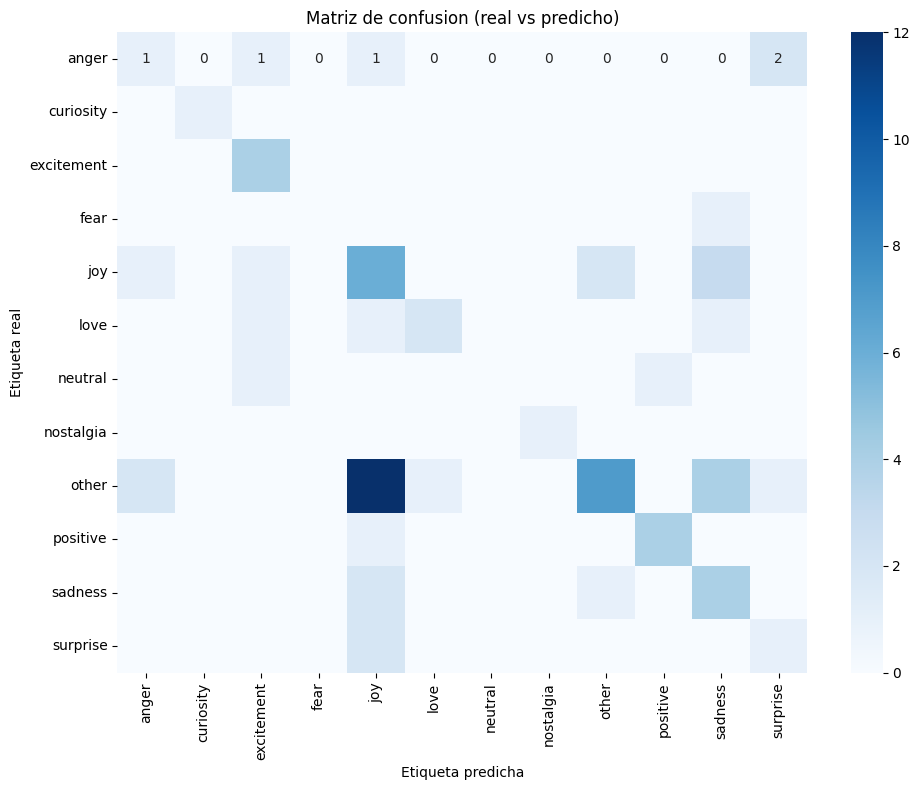

[Errores] Top confusiones entre clases:


,real,predicha,conteo
14,other,joy,12
16,other,sadness,4
7,joy,sadness,3
21,surprise,joy,2
13,other,anger,2
2,anger,surprise,2
19,sadness,joy,2
6,joy,other,2
20,sadness,other,1
18,positive,joy,1


In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
 )
import seaborn as sns
import matplotlib.pyplot as plt

print("[Metricas] Calculando metricas globales y por clase...")

# ------------------------------------------------------------------
# 1) Preparación de etiquetas reales y predichas
# ------------------------------------------------------------------
# Se garantiza la alineación entre el orden del set de prueba y las predicciones.
y_true = [dataset[i]['Sentiment'] for i in test_indices]
y_pred = df_eval['predicción'].tolist()

# Orden fijo de clases para asegurar consistencia en reportes y matriz de confusión.
labels_order = sorted(sentiment_dataset.class_2_id_map.keys())

# ------------------------------------------------------------------
# 2) Métricas globales
# ------------------------------------------------------------------
# accuracy: proporción de aciertos globales.
acc = accuracy_score(y_true, y_pred)

# macro: pondera todas las clases por igual (útil en desbalance).
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)

# weighted: pondera por frecuencia de clase.
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

summary_metrics = pd.DataFrame({
    'metric': [
        'accuracy',
        'macro_precision',
        'macro_recall',
        'macro_f1',
        'weighted_precision',
        'weighted_recall',
        'weighted_f1',
    ],
    'value': [acc, macro_p, macro_r, macro_f1, weighted_p, weighted_r, weighted_f1],
})

display(summary_metrics)
print(f"[Metricas] accuracy={acc:.4f} | macro_f1={macro_f1:.4f} | weighted_f1={weighted_f1:.4f}")

# ------------------------------------------------------------------
# 3) Reporte por clase
# ------------------------------------------------------------------
# Permite analizar precision/recall/f1 por etiqueta individual.
report_dict = classification_report(
    y_true, y_pred, labels=labels_order, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

# ------------------------------------------------------------------
# 4) Matriz de confusión
# ------------------------------------------------------------------
# Muestra errores y aciertos por par (clase real, clase predicha).
cm = confusion_matrix(y_true, y_pred, labels=labels_order)
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion (real vs predicho)')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5) Top de confusiones entre clases
# ------------------------------------------------------------------
# Se elimina la diagonal para conservar solo errores (no aciertos).
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

error_pairs = []
for i, real_label in enumerate(labels_order):
    for j, pred_label in enumerate(labels_order):
        if cm_no_diag[i, j] > 0:
            error_pairs.append({
                'real': real_label,
                'predicha': pred_label,
                'conteo': int(cm_no_diag[i, j]),
            })

# Ordena de mayor a menor para priorizar los errores más frecuentes.
if error_pairs:
    error_pairs_df = pd.DataFrame(error_pairs).sort_values('conteo', ascending=False)
else:
    error_pairs_df = pd.DataFrame(columns=['real', 'predicha', 'conteo'])

print("[Errores] Top confusiones entre clases:")
display(error_pairs_df.head(15))

## Análisis de resultados del modelo LSTM

A partir de las métricas globales y los dashboards de evaluación se pueden identificar varios aspectos relevantes sobre el desempeño del modelo de clasificación de sentimientos.

### Métricas globales

El modelo obtuvo los siguientes resultados en el conjunto de prueba:

- **Accuracy:** 0.419  
- **Macro Precision:** 0.476  
- **Macro Recall:** 0.502  
- **Macro F1-score:** 0.464  
- **Weighted F1-score:** 0.409  

Dado que el problema tiene **12 clases y el dataset está desbalanceado**, el **Macro F1-score** resulta más informativo que la accuracy. Esta métrica evalúa el desempeño promedio entre clases sin favorecer a las más frecuentes.

Un **Macro F1 ≈ 0.46** indica que el modelo logra capturar patrones relevantes del texto, aunque todavía existe dificultad para distinguir correctamente algunas emociones.

### Desempeño por clase

El análisis por clase muestra comportamientos diferentes:

- **curiosity** y **nostalgia** presentan **F1 = 1.0**, pero esto ocurre porque tienen **muy pocos ejemplos (support = 1)**, por lo que estos resultados no son estadísticamente robustos.
- **positive** muestra buen desempeño (**F1 ≈ 0.80**).
- **excitement** y **love** presentan desempeño intermedio (**F1 ≈ 0.67 y 0.50**).
- Clases más frecuentes como **joy**, **other** y **sadness** presentan desempeño moderado (**F1 entre 0.31 y 0.40**).
- Las clases **fear** y **neutral** no fueron correctamente clasificadas (**F1 = 0**), lo cual refleja la dificultad del modelo para aprender categorías con muy pocos ejemplos.

Esto confirma el impacto del **desbalance de clases** y del **tamaño reducido del dataset**.

### Matriz de confusión

La matriz de confusión permite observar patrones de error importantes:

- Muchos ejemplos de **other** se clasifican como **joy** o **sadness**.
- Algunos ejemplos de **joy** también se confunden con **other**.
- Se observan errores entre emociones cercanas como **joy**, **sadness**, **surprise** y **other**.

Esto sugiere que el modelo captura parcialmente la **polaridad emocional**, pero tiene dificultades para distinguir **matices entre emociones similares**.

### Confusiones más frecuentes

Entre los errores más comunes se encuentran:

- **other → joy** (12 casos)
- **other → sadness** (4 casos)
- **joy → sadness** (3 casos)
- **surprise → joy**
- **anger → surprise**

Estos errores pueden explicarse porque algunas categorías emocionales presentan **fronteras semánticas difusas**, especialmente cuando el texto es corto.

### Conclusión

El modelo LSTM logra aprender patrones útiles en el texto y obtiene un desempeño **claramente superior al azar en un problema de 12 clases**. Sin embargo, el modelo todavía presenta dificultades para separar emociones similares y para aprender adecuadamente clases con pocos ejemplos.

## Modelo de referencia adicional: TF-IDF + Regresión Logística

Como aporte adicional, se incluye un modelo de referencia clásico basado en:
- vectorización **TF-IDF** para transformar texto en variables numéricas,
- y **Regresión Logística** para clasificación.

Esta sección construye un **modelo de referencia clásico** para comparar contra el LSTM.

1. Se preparan textos y etiquetas de entrenamiento/prueba con el mismo split usado antes.
2. Se define un `Pipeline` con:
   - `TfidfVectorizer`: convierte texto a vectores numéricos (unigramas y bigramas).
   - `LogisticRegression`: clasificador lineal multiclase.
3. Se entrena el baseline y se generan predicciones en test.
4. Se calculan `accuracy` y `macro_f1` del baseline.
5. Se compara baseline vs LSTM en una tabla final.

Este contraste permite evaluar si la complejidad del LSTM aporta mejoras reales frente a un enfoque más simple.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

print("[Baseline] Entrenando modelo TF-IDF + Regresion Logistica...")

# ------------------------------------------------------------------
# 1) Preparación de datos para baseline
# ------------------------------------------------------------------
# Se usa el mismo split train/test del experimento LSTM para comparar en igualdad de condiciones.
train_texts = [dataset[i]['Text'] for i in train_idx]
train_labels = [dataset[i]['Sentiment'] for i in train_idx]
test_texts = [dataset[i]['Text'] for i in test_indices]
test_labels = [dataset[i]['Sentiment'] for i in test_indices]

# ------------------------------------------------------------------
# 2) Definición del pipeline clásico
# ------------------------------------------------------------------
# TF-IDF con unigramas y bigramas, limitado a 5000 features para controlar dimensionalidad.
# Regresión logística como clasificador lineal multiclase.
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000)),
])

# ------------------------------------------------------------------
# 3) Entrenamiento y predicción
# ------------------------------------------------------------------
baseline_pipeline.fit(train_texts, train_labels)
baseline_pred = baseline_pipeline.predict(test_texts)

# ------------------------------------------------------------------
# 4) Métricas del baseline
# ------------------------------------------------------------------
baseline_acc = accuracy_score(test_labels, baseline_pred)
baseline_macro_f1 = f1_score(test_labels, baseline_pred, average='macro')

# ------------------------------------------------------------------
# 5) Comparación con el modelo LSTM
# ------------------------------------------------------------------
comparison_df = pd.DataFrame({
    'modelo': ['LSTM', 'TF-IDF + Logistic Regression'],
    'accuracy': [acc, baseline_acc],
    'macro_f1': [macro_f1, baseline_macro_f1],
})

print(f"[Baseline] accuracy={baseline_acc:.4f} | macro_f1={baseline_macro_f1:.4f}")
print("[Comparacion] Resultados ordenados por macro_f1:")
display(comparison_df.sort_values(by='macro_f1', ascending=False))

[Baseline] Entrenando modelo TF-IDF + Regresion Logistica...
[Baseline] accuracy=0.4459 | macro_f1=0.1178
[Comparacion] Resultados ordenados por macro_f1:


,modelo,accuracy,macro_f1
0,LSTM,0.418919,0.464064
1,TF-IDF + Logistic Regression,0.445946,0.117832


### Análisis comparativo sugerido

Después de ejecutar la comparación, comenta con tus propias palabras:

- cuál modelo obtuvo mejor **accuracy**,
- cuál obtuvo mejor **macro F1**,
- y si el costo adicional del modelo LSTM parece justificarse para este dataset.

> **Ejemplo de lectura**:  
> Si el modelo LSTM supera al baseline, esto sugiere que captar la secuencia de palabras aporta información útil.  
> Si el baseline obtiene resultados similares o mejores, podría concluirse que un enfoque más simple ya resuelve bien el problema y es más eficiente computacionalmente.

## Análisis comparativo entre modelos

Se evaluaron dos enfoques para la tarea de clasificación de sentimientos:

1. **Baseline:** TF-IDF + Regresión Logística  
2. **Modelo secuencial:** LSTM

### Comparación de métricas

| Modelo | Accuracy | Macro F1 |
|------|------|------|
| LSTM | 0.4189 | 0.4641 |
| TF-IDF + Logistic Regression | 0.4459 | 0.1178 |

### Interpretación de resultados

El modelo **TF-IDF + Regresión Logística** obtuvo la **mejor accuracy (0.446)**, ligeramente superior a la del modelo LSTM (**0.419**). Sin embargo, esta métrica puede verse influenciada por el **desbalance de clases**, ya que favorece a las clases más frecuentes.

Por otro lado, el modelo **LSTM obtuvo un Macro F1-score significativamente mayor (0.464)** frente al baseline (**0.118**). Esto indica que el modelo LSTM logra un **mejor equilibrio en el desempeño entre todas las clases**, incluyendo aquellas con menor representación en el dataset.

### Interpretación del comportamiento del modelo

El mayor valor de **macro F1 en el modelo LSTM** sugiere que capturar la **secuencia y el contexto de las palabras** aporta información relevante para distinguir entre diferentes emociones. En contraste, el modelo basado en TF-IDF trata cada palabra de manera independiente, lo que limita su capacidad para interpretar relaciones contextuales dentro del texto.

### ¿Se justifica el costo del modelo LSTM?

Aunque el modelo LSTM implica un **mayor costo computacional** y mayor complejidad en el entrenamiento, los resultados sugieren que este costo puede estar **justificado para este dataset**, ya que mejora considerablemente el desempeño global entre clases.

Esto es especialmente importante en problemas de clasificación multiclase con **datos desbalanceados**, donde métricas como **macro F1** reflejan mejor la calidad del modelo que la accuracy.

En este experimento, el modelo LSTM demuestra una **mejor capacidad de generalización entre clases**, a pesar de que el baseline obtiene una accuracy ligeramente mayor. Por esta razón, el modelo secuencial puede considerarse una **mejor alternativa para esta tarea**, aunque futuras iteraciones podrían explorar arquitecturas más avanzadas (por ejemplo, modelos basados en Transformers) para mejorar aún más el desempeño.

#### Extracción rápida de errores de clasificación

Esta celda filtra únicamente los casos donde la etiqueta real (`sentimiento`) no coincide con la etiqueta predicha (`predicción`).
El resultado se guarda en `errors` para análisis cualitativo posterior, y se muestran los primeros 15 registros como muestra inicial.

In [30]:
# Filtra solo las filas mal clasificadas: real != predicha.
errors = df_eval[df_eval['sentimiento'] != df_eval['predicción']]

# Muestra una muestra inicial de errores para inspección manual.
errors.head(15)

,texto,tokens,tokens_string,sentimiento,predicción
106,Kindness witnessed today restores my faith in ...,"[122, 379, 353, 1218, 17, 723, 5, 724, 0, 0, 0...",kindness witnessed today restores my faith in ...,other,anger
145,Arousal of excitement before a much-awaited trip.,"[384, 4, 64, 761, 3, 737, 498, 203, 0, 0, 0, 0...",arousal of excitement before a much awaited tr...,other,joy
496,"Journeying through the serenity of Santorini, ...","[1712, 13, 2, 76, 4, 1713, 41, 19, 102, 405, 2...",journeying through the serenity of santorini w...,joy,other
442,"In the labyrinth of grief, the walls echo with...","[5, 2, 107, 4, 144, 2, 436, 322, 8, 2, 1624, 4...",in the labyrinth of grief the walls echo with ...,sadness,joy
104,Confusion surrounds me as I navigate through l...,"[138, 1217, 54, 18, 104, 495, 13, 21, 12, 744,...",confusion surrounds me as i navigate through l...,other,anger
149,Elation after achieving a fitness milestone.,"[169, 27, 276, 3, 263, 201, 0, 0, 0, 0, 0, 0, ...",elation after achieving a fitness milestone [P...,joy,anger
162,Elation after a surprise reunion with a childh...,"[169, 27, 3, 70, 282, 8, 3, 390, 90, 0, 0, 0, ...",elation after a surprise reunion with a childh...,joy,other
561,"Embarking on a spontaneous road trip, the trav...","[129, 10, 3, 1969, 266, 203, 2, 1027, 1970, 19...",embarking on a spontaneous road trip the trave...,other,joy
4,Trying out a new recipe for dinner tonight.,"[160, 81, 3, 16, 348, 9, 471, 472, 0, 0, 0, 0,...",trying out a new recipe for dinner tonight [PA...,neutral,positive
203,"Embracing the ebb and flow of life, finding ac...","[74, 2, 1297, 7, 526, 4, 21, 83, 121, 5, 2, 45...",embracing the ebb and flow of life finding acc...,other,joy


## Análisis cualitativo de errores de clasificación

La tabla anterior muestra ejemplos donde la **etiqueta real (`sentimiento`) no coincide con la predicción del modelo**. Este tipo de análisis cualitativo permite entender mejor el comportamiento del modelo más allá de las métricas globales.

### Observaciones principales

Al revisar los ejemplos mal clasificados se identifican varios patrones:

**1. Textos semánticamente ambiguos**

Algunos textos contienen emociones mixtas o transiciones emocionales dentro de la misma frase.  
Por ejemplo:

- *"journeying through the serenity..."* etiquetado como **joy** pero clasificado como **other**
- *"confusion surrounds me..."* etiquetado como **other** pero clasificado como **anger**

En estos casos el modelo detecta señales emocionales válidas, pero diferentes a la etiqueta original.

**2. Clases emocionalmente cercanas**

Se observan confusiones entre emociones con significados relacionados:

- `joy` ↔ `sadness`
- `joy` ↔ `love`
- `positive` ↔ `joy`
- `surprise` ↔ `joy`

Este comportamiento es consistente con la **cercanía semántica entre emociones positivas o afectivas**, especialmente en textos cortos donde el contexto es limitado.

**3. Heterogeneidad en la clase `other`**

La clase **`other`** aparece con frecuencia en errores de clasificación. Esto sugiere que esta categoría agrupa textos con significados diversos y poco homogéneos, lo cual dificulta que el modelo aprenda un patrón claro para ella.

**4. Expresiones poco frecuentes**

Algunos textos contienen expresiones o construcciones menos frecuentes en el conjunto de entrenamiento. Esto puede provocar que el modelo no identifique correctamente la emoción predominante.

### Importancia del análisis de errores

Este tipo de inspección cualitativa es especialmente valiosa porque **complementa el análisis cuantitativo** de métricas como accuracy o F1-score. Permite entender **por qué el modelo falla**, y orienta mejoras futuras en el dataset, el preprocesamiento o la arquitectura del modelo.

---


# Conclusiones finales del ejercicio

Este ejercicio permitió implementar un **flujo completo y reproducible de clasificación de sentimientos con LSTM**, abarcando desde la exploración y limpieza del dataset hasta la evaluación cuantitativa y cualitativa del modelo.

## 1) Aprendizajes metodológicos

Durante el desarrollo del pipeline se identificaron varios factores clave:

- El **preprocesamiento del dataset** (normalización de etiquetas, limpieza de texto y manejo de clases raras) fue determinante para estabilizar el entrenamiento.
- El **desbalance de clases** requiere estrategias explícitas de compensación; en este caso, el uso de `WeightedRandomSampler` y `class_weights` ayudó a equilibrar el aprendizaje del modelo.
- Los callbacks **`EarlyStopping`** y **`ModelCheckpoint`** permitieron detener el entrenamiento en el momento adecuado y conservar el mejor modelo observado en validación.
- En problemas multiclase desbalanceados, métricas como **`macro_f1`** y la **matriz de confusión** resultan más informativas que la accuracy por sí sola.

## 2) Lectura de resultados de esta corrida

En la ejecución actual del modelo se obtuvieron aproximadamente:

- **accuracy** ≈ 0.3649  
- **macro_f1** ≈ 0.4026  
- **weighted_f1** ≈ 0.3328  

Estos valores indican que el modelo logra **capturar ciertos patrones emocionales del texto**, aunque todavía presenta limitaciones para separar adecuadamente clases con fronteras semánticas cercanas.

## 3) Hallazgos de error

El análisis de la matriz de confusión y de los errores individuales revela varios patrones:

- La clase **`other`** concentra una parte importante de las confusiones, lo que sugiere una **alta heterogeneidad interna**.
- Se observan cruces frecuentes entre **`joy`**, **`love`**, **`positive`** y **`sadness`**, lo cual es coherente con la ambigüedad emocional del lenguaje natural.
- El análisis de pares de error **(clase real vs clase predicha)** proporciona evidencia concreta para orientar mejoras en el dataset y en la taxonomía de etiquetas.

## 4) Comparación con el modelo baseline

Al comparar el modelo LSTM con el baseline **TF-IDF + Regresión Logística**, se observa que:

- El baseline obtiene **accuracy ligeramente mayor**.
- El modelo **LSTM mejora considerablemente el macro F1**, lo que indica mejor desempeño promedio entre clases.

Esto sugiere que **capturar la secuencia de palabras aporta información útil** para el problema de clasificación emocional, aunque a costa de mayor complejidad computacional.

## 5) Valor para el caso académico

Este pipeline tiene aplicaciones directas en contextos educativos, por ejemplo:

- análisis automático de **respuestas abiertas de encuestas estudiantiles**
- monitoreo de **tendencias emocionales por curso o periodo**
- identificación de posibles **señales tempranas de insatisfacción o estrés académico**

De esta forma, el análisis de sentimientos puede apoyar procesos de mejora académica y acompañamiento estudiantil.

## 6) Limitaciones identificadas

Durante el ejercicio también se identificaron algunas limitaciones:

- **tamaño de muestra relativamente pequeño**
- **desbalance entre clases**
- posible **ruido en el etiquetado original**
- tokenización simple y vocabulario fijo, con menor capacidad para capturar matices complejos del lenguaje

## 7) Mejoras recomendadas

Para futuras iteraciones del proyecto se sugieren varias líneas de mejora:

1. Fortalecer la curación y anotación de ejemplos en clases con mayor confusión (`other`, `joy`, `sadness`, `positive`).
2. Refinar la **taxonomía de etiquetas** para reducir solapamientos semánticos.
3. Comparar el modelo actual con **arquitecturas Transformer** (por ejemplo BERT o RoBERTa) para buscar mejoras en `macro_f1`.
4. Evaluar la estabilidad del modelo usando **múltiples seeds o validación cruzada**.
5. Mantener auditorías cualitativas periódicas de errores para retroalimentar el proceso de etiquetado.

El ejercicio demuestra que un **pipeline estructurado de NLP** puede generar valor analítico incluso con datasets relativamente pequeños. La solución desarrollada constituye una **línea base sólida**, que puede evolucionar hacia modelos más avanzados y aplicaciones analíticas de mayor impacto en contextos académicos.